In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

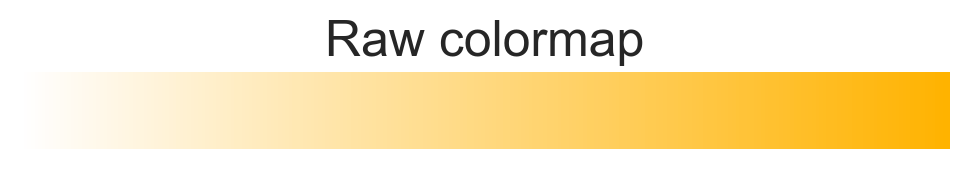

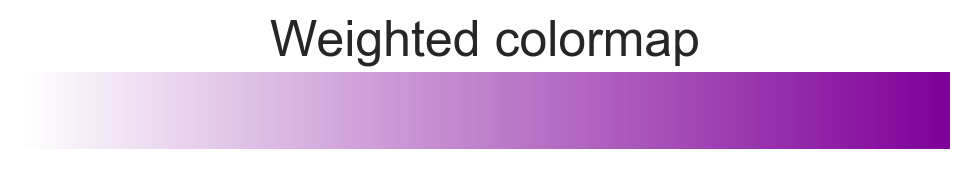

In [2]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "sans-serif",
        "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)


# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list(
    "raw", [COL_WHITE, COL_RAW_RGB], N=256
)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [3]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("~/Projects/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/home/galkepler/Projects/neuroaging/figures/fig2_clustering")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [4]:
metrics = ["adc","gm_vol"]
distribution_metric = "qfmean"

all_data = {}
for metric in metrics:
    data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(drop=True)

    data["age_squared"] = data["age_at_scan"] ** 2
    data["sex"] = data["sex"].map({"M": 0, "F": 1})
    all_data[metric] = data

/tmp/ipykernel_1341150/3217849398.py:6: DtypeWarning: Columns (16,22) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(drop=True)
/tmp/ipykernel_1341150/3217849398.py:6: DtypeWarning: Columns (1,7) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(drop=True)


In [5]:
metric_col = "volume" if metric == "gm_vol" else distribution_metric

In [6]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [7]:
def assign_weights_by_population(
    data: pd.DataFrame,
    population_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    range_start: str = "range_start",
    range_end: str = "range_end",
    total: str = "total",
) -> np.ndarray:
    """
    Post-stratification weights so the age distribution of *data*
    matches an external reference.

    - Accepts integer or float ages.
    - Handles boundary ages (include_lowest=True).
    - Leaves bins with zero sample untouched (weight=0 → later dropped).
    - Returns weights whose mean == 1 across *non-zero* weights.
    """

    # 1. Make sure population bins are well-formed
    pop = (
        population_df[[range_start, range_end, total]]
        .sort_values(range_start)
        .reset_index(drop=True)
    )
    if (pop[range_end] <= pop[range_start]).any():
        raise ValueError("Each range_end must exceed range_start.")
    if (pop[range_start].iloc[1:].values < pop[range_end].iloc[:-1].values).any():
        raise ValueError("Age bins overlap or are not strictly increasing.")

    # 2. Bin edges for pd.cut  →  [..., last_end]  (right-inclusive)
    bin_edges = pop[range_start].tolist() + [pop[range_end].iloc[-1]]

    # Population proportions (works for % or counts)
    pop_prop = pop[total] / pop[total].sum()

    # 3. Assign each participant to a bin
    sample_bins = pd.cut(
        data[age_col],
        bins=bin_edges,
        right=True,  # include right edge
        include_lowest=True,  # include first left edge
        labels=pop.index,  # integer labels 0..n-1
    )

    # 4. Sample distribution
    sample_counts = sample_bins.value_counts(sort=False)
    sample_prop = sample_counts / sample_counts.sum()

    # 5. Weight lookup  (population / sample)  — careful with zeros
    weight_lookup = pop_prop / sample_prop.replace(0, np.nan)

    # 6. Map to rows; bins with zero sample → NaN weight → drop later
    w = sample_bins.map(weight_lookup).to_numpy()

    # Assign *zero* weight (instead of 1) to rows that were NaN
    w = np.where(np.isnan(w), 0.0, w)

    # 7. Rescale so mean(weight > 0) == 1
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    return w

In [8]:
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
def compute_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    start_col: str = "range_start",
    end_col: str = "range_end",
    pop_total_col: str = "total",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Post-stratification weights so that the age distribution of *sample_df*
    matches an external population distribution supplied in *pop_df*.

    Parameters
    ----------
    sample_df : DataFrame with an ``age_col`` column (years; int or float).
    pop_df    : DataFrame with columns
                    [start_col, end_col, pop_total_col].
                * Values in ``pop_total_col`` can be counts **or** percentages
                  (they are internally re-scaled to proportions).
                * The row order doesn’t matter; they will be sorted.
    cap       : Optional float.  If provided, weights are truncated at
                ``cap × mean(weight)`` and then re-scaled so mean(weight)=1.
    return_bin_table : If True, also return a DataFrame summarising
                       n_sample, n_pop, and weight_factor for every bin.

    Returns
    -------
    weights   : 1-D numpy array aligned with ``sample_df.index``.
    bin_table : (optional) tidy per-bin summary (see above).
    """

    # 1 ── tidy & validate the population table --------------------------------
    pop = (
        pop_df[[start_col, end_col, pop_total_col]]
        .dropna()
        .astype({start_col: int, end_col: int, pop_total_col: float})
        .sort_values(start_col)  # your CSV is descending; fix that
        .reset_index(drop=True)
    )

    if (pop[end_col] <= pop[start_col]).any():
        raise ValueError("Each range_end must exceed range_start.")

    if (pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values).any():
        overlap = pop.iloc[
            np.where(pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values)[0] + 1
        ][[start_col, end_col]]
        raise ValueError(
            "Age bins overlap (rows shown below) — "
            "merge / correct them before weighting:\n"
            f"{overlap}"
        )

    # 2 ── build right-inclusive bin edges  (···| s_i  …  e_i | s_{i+1} …) ----
    edges = pop[start_col].tolist() + [pop[end_col].iloc[-1]]

    # 3 ── assign every participant to a bin -----------------------------------
    s_bins = pd.cut(
        sample_df[age_col],
        bins=edges,
        right=True,
        include_lowest=True,
        labels=pop.index,  # categorical labels 0,1,…
    )

    # 4 ── compute *sample* and *population* proportions per bin --------------
    n_sample = s_bins.value_counts(sort=False).sort_index()
    prop_sample = n_sample / n_sample.sum()

    prop_pop = pop[pop_total_col] / pop[pop_total_col].sum()

    # 5 ── weight factor = pop_prop / sample_prop ------------------------------
    weight_factor = prop_pop / prop_sample.replace(0, np.nan)  # avoid /0 → NaN

    # 6 ── map factor back to each row ----------------------------------------
    w = s_bins.map(weight_factor).astype(float).to_numpy()
    w = np.where(np.isnan(w), 0.0, w)  # rows that fell outside bins → 0

    # 7 ── optional weight truncation (winsorisation) --------------------------
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean()
        w = np.clip(w, 0, cap * mean_pos)

    # 8 ── re-scale so mean(weight > 0) == 1 -----------------------------------
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    # 9 ── return --------------------------------------------------------------
    if return_bin_table:
        bin_tbl = pd.DataFrame(
            {
                "n_sample": n_sample,
                "n_pop": prop_pop * n_sample.sum(),  # rescaled to sample size
                "prop_sample": prop_sample,
                "prop_pop": prop_pop,
                "weight_factor": weight_factor,
            }
        )
        return w, bin_tbl

    return w

In [9]:
# assign weights
for _, data in all_data.items():
    data["weight"], _ = compute_poststrat_weights(
        data,
        israel_population,
        age_col="age_at_scan",
        cap=None,  # try None first; if still spiky, use 4 or 5
        return_bin_table=True,
    )

In [10]:
from statsmodels.formula.api import ols, wls
import statsmodels.formula.api as smf


def regional_models(region_data: pd.DataFrame, metric_col: str, model: str, covariates: list):
    """
    Fit a linear model to the data for each region.
    """
    # Fit the model
    if model == "ols":
        model = ols(f"{metric_col} ~ {' + '.join(covariates)}", data=region_data)
    elif model == "wls":
        model = wls(
            f"{metric_col} ~ {' + '.join(covariates)}",
            data=region_data,
            weights=region_data["weight"],
        )
    else:
        raise ValueError("Model must be either 'ols' or 'wls'.")

    # Fit the model
    results = model.fit()

    # Return the results
    return results

In [11]:
# from tqdm import tqdm

# # Set up dataframes to store results
# lin_unw, lin_w, quad_unw, quad_w = parcels.copy(), parcels.copy(), parcels.copy(), parcels.copy()

# covariates = ["age_at_scan", "sex"]
# if metric == "gm_vol":
#     covariates += ["tiv"]

# for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
#     region_data = data[data[region_col] == row[region_col]].copy()
#     region_data.rename(columns={metric_col: "value"}, inplace=True)
#     for results_df, model, is_quadratic in zip(
#         [lin_unw, lin_w, quad_unw, quad_w],
#         ["ols", "wls", "ols", "wls"],
#         [False, False, True, True],
#     ):
#         # Fit the model
#         if is_quadratic:
#             region_data["age_squared"] = region_data["age_at_scan"] ** 2
#             results = regional_models(region_data, "value", model, covariates + ["age_squared"])
#         else:
#             results = regional_models(region_data, "value", model, covariates)

#         # Store the results
#         results_df.loc[i, "model"] = results
#         results_df.loc[i, "pvalue"] = results.f_pvalue
#         results_df.loc[i, "r2"] = results.rsquared
#         results_df.loc[i, "r2_adj"] = results.rsquared_adj
#         results_df.loc[i, "n"] = len(region_data)
#         # if i == 405 and model == "wls" and is_quadratic:
#         #     a = results

In [12]:
from tqdm import tqdm


regional_results = {}

for metric, data in all_data.items():
    metric_col = "volume" if metric == "gm_vol" else distribution_metric
    # Set up dataframes to store results
    quad_w, lin_w = parcels.copy(), parcels.copy()

    covariates = ["age_at_scan", "sex"]
    if metric == "gm_vol":
        covariates += ["tiv"]

    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        region_data = data[data[region_col] == row[region_col]].copy()
        region_data.rename(columns={metric_col: "value"}, inplace=True)
        lin_model = smf.wls(
            "value ~ " + " + ".join(covariates),
            data=region_data,
            weights=region_data["weight"],
        ).fit()
        quad_model = smf.wls(
            "value ~ " + " + ".join(covariates) + " + I(age_at_scan ** 2)",
            data=region_data,
            weights=region_data["weight"],
        ).fit()

        for results_df, model, is_quadratic in zip(
            [lin_w, quad_w],
            [lin_model, quad_model],
            [False, True],
        ):
            # Store the results
            results_df.loc[i, "model"] = model
            results_df.loc[i, "pvalue"] = model.f_pvalue
            results_df.loc[i, "r2"] = model.rsquared
            results_df.loc[i, "r2_adj"] = model.rsquared_adj
            results_df.loc[i, "n"] = len(region_data)
            results_df.loc[i, "intercept"] = model.params["Intercept"]
            results_df.loc[i, "t_intercept"] = model.tvalues["Intercept"]
            results_df.loc[i, "pvalue_intercept"] = model.pvalues["Intercept"]
            results_df.loc[i, "beta1"] = model.params["age_at_scan"]
            results_df.loc[i, "t_beta1"] = model.tvalues["age_at_scan"]
            results_df.loc[i, "pvalue_beta1"] = model.pvalues["age_at_scan"]

            if is_quadratic:
                results_df.loc[i, "beta2"] = model.params["I(age_at_scan ** 2)"]
                results_df.loc[i, "t_beta2"] = model.tvalues["I(age_at_scan ** 2)"]
                results_df.loc[i, "pvalue_beta2"] = model.pvalues["I(age_at_scan ** 2)"]
            else:
                results_df.loc[i, "beta2"] = 0
                results_df.loc[i, "t_beta2"] = 0
                results_df.loc[i, "pvalue_beta2"] = 1
            # if i == 405 and model == "wls" and is_quadratic:
    regional_results[metric] = {
        "lin_w": lin_w,
        "quad_w": quad_w,
    }
            #     a = results

Fitting models:   0%|          | 0/454 [00:00<?, ?it/s]

Fitting models: 100%|██████████| 454/454 [00:07<00:00, 60.92it/s]


In [13]:
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests

for metric, results in regional_results.items():
    w_compare = parcels.copy()

    # do f test to compare between quadratic and linear models
    for i, row in tqdm(parcels.iterrows(), total=parcels.shape[0], desc="Fitting models"):
        # collect models
        model1 = results["lin_w"].loc[i, "model"]
        model2 = results["quad_w"].loc[i, "model"]
        f, p, _ = model2.compare_f_test(model1)
        w_compare.loc[i, "f"] = f
        w_compare.loc[i, "pvalue"] = p
        w_compare.loc[i, "n"] = model1.nobs
        w_compare.loc[i, "AIC(lin)"] = model1.aic
        w_compare.loc[i, "AIC(quad)"] = model2.aic
        w_compare.loc[i, "delta_AIC"] = model2.aic - model1.aic
        w_compare["log(f)"] = np.log(w_compare["f"])
    # Save the comparison results
    w_compare["p_corrected"] = multipletests(
        w_compare["pvalue"], method="fdr_bh"
    )[1]  # Benjamini-Hochberg correction
    regional_results[metric]["w_compare"] = w_compare
        # do f test to compare between quadratic and linear models
        # model1 = lin_unw.loc[i, "model"]
        # model2 = quad_unw.loc[i, "model"]
        # f, p, _ = model2.compare_f_test(model1)
        # unw_compare.loc[i, "f"] = f
        # unw_compare.loc[i, "pvalue"] = p
        # unw_compare.loc[i, "n"] = model1.nobs
        # weighted

Fitting models: 100%|██████████| 454/454 [00:00<00:00, 1296.85it/s]


In [14]:
features = []

weight_by = "r2_adj"
weights = []
# base_features = ["intercept", "beta1", "beta2"]
base_features = ["beta1", "beta2"]

for metric in metrics:
    for feature in base_features:
        features.append(f"{metric}_{feature}")

features_df = parcels.copy()
for i, row in parcels.iterrows():
    region_weights = []
    for metric in metrics:
        quad_comp_pvalue = regional_results[metric]["w_compare"].loc[i, "p_corrected"]
        if quad_comp_pvalue < 0.05:
            region_weights.append(
                regional_results[metric]["quad_w"].loc[i, weight_by]
            )
            for feature in base_features:
                features_df.loc[i, f"{metric}_{feature}"] = regional_results[metric]["quad_w"].loc[i, feature]
                
        else:
            region_weights.append(
                regional_results[metric]["lin_w"].loc[i, weight_by]
            )
            for feature in base_features:
                features_df.loc[i, f"{metric}_{feature}"] = regional_results[metric]["lin_w"].loc[i, feature]
    weights.append(np.mean(region_weights))
    # refine weights
weights = np.clip(weights, 0.1, 1.0)
weights /= np.sum(weights) * len(parcels)
    # break

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture  # Changed from sklearn.cluster.KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

k_range = range(2, 20)  # KMeans clusters from 2 to 10

# features = ["lin_intercept", "lin_beta1", "quad_intercept", "quad_beta1", "quad_beta2"]
# features = ["lin_intercept", "lin_beta1",  "quad_beta1", "quad_beta2", "quad_r2_adj"]

# X_quad = quad_w.copy().rename(columns={"intercept":"quad_intercept", "beta1":"quad_beta1", "beta2":"quad_beta2", "r2_adj":"quad_r2_adj"})
# X_lin = lin_w[["intercept", "beta1", "r2_adj"]].rename(columns={"intercept":"lin_intercept", "beta1":"lin_beta1", "r2_adj":"lin_r2_adj"})

# features_df = pd.concat([X_quad, X_lin], axis=1)
X = features_df[features]  # Select only the relevant features


In [32]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.cross_decomposition import CCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
# Assume these are defined from earlier:
# X = coef_matrix_std  # Your standardized coefficient matrix (n_regions x 6)
# weights = ...  # Your computed weights (array of length n_regions, e.g., average R²)

gm_features = X_scaled_df.filter(regex="^gm_")
md_features = X_scaled_df.filter(regex="^adc_")

cca = CCA(n_components=2)
cca.fit(gm_features, md_features)
# Transform to canonical variates
gm_canon, md_canon = cca.transform(gm_features, md_features)  # Each is (400, 2)



In [34]:
correlations = [np.corrcoef(gm_canon[:, i], md_canon[:, i])[0, 1] for i in range(cca.n_components)]
# Step 3: Fuse the variates (e.g., concatenate for full info)
fused_feats = np.hstack([gm_canon, md_canon])  # (400, 4) if n_components=2
# Alternative: Average paired variates for emphasis on shared variance
# fused_feats = (gm_canon + md_canon) / 2  # (400, 2)

In [35]:
# Normalize weights to probabilities (must sum to 1)
probs = weights / np.sum(weights)

# Number of regions (inferred from X)
n_regions = len(X)  # Or use len(parcels) if that's your variable

# Resample indices with replacement, proportional to probs
n_resamples = n_regions * 10  # e.g., 10x oversampling; adjust as needed
sampled_indices = np.random.choice(n_regions, size=n_resamples, replace=True, p=probs)
# Create resampled data using the sampled indices
resampled_data = fused_feats[sampled_indices]  # This is now weighted!

In [51]:

X_scaled_df = fused_feats.copy()

clustering_results = pd.DataFrame(index=k_range, columns=["aic", "bic", "n_clusters"])

for k in tqdm(k_range, desc="Fitting GMM", unit="clusters"):
    # Create a pipeline with standard scaling and KMeans
    gmm = GaussianMixture(
        n_components=k,
        random_state=42,
        n_init=100,
        # covariance_type="full",  # Use full covariance for GMM
    )

    # Fit the model
    gmm.fit(X_scaled_df)

    # Get the AIC and BIC
    aic = gmm.aic(X_scaled_df)
    bic = gmm.bic(X_scaled_df)

    # Get the cluster labels
    labels = gmm.predict(X_scaled_df)

    # Store results
    clustering_results.loc[k, "aic"] = aic
    clustering_results.loc[k, "bic"] = bic
    clustering_results.loc[k, "n_clusters"] = k
    clustering_results.loc[k, "model"] = gmm

Fitting GMM: 100%|██████████| 18/18 [00:43<00:00,  2.39s/clusters]


In [52]:
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
# X_scaled_df = X.copy()

# clustering_results = pd.DataFrame(index=k_range, columns=["aic", "bic", "n_clusters"])

# for k in tqdm(k_range, desc="Fitting GMM", unit="clusters"):
#     # Create a pipeline with standard scaling and KMeans
#     gmm = GaussianMixture(
#         n_components=k,
#         random_state=42,
#         n_init=100,
#         # covariance_type="full",  # Use full covariance for GMM
#     )

#     # Fit the model
#     gmm.fit(X_scaled_df)

#     # Get the AIC and BIC
#     aic = gmm.aic(X_scaled_df)
#     bic = gmm.bic(X_scaled_df)

#     # Get the cluster labels
#     labels = gmm.predict(X_scaled_df)

#     # Calculate silhouette score
#     silhouette = silhouette_score(X, labels)

#     # Store results
#     clustering_results.loc[k, "aic"] = aic
#     clustering_results.loc[k, "bic"] = bic
#     clustering_results.loc[k, "silhouette"] = silhouette
#     clustering_results.loc[k, "n_clusters"] = k
#     clustering_results.loc[k, "model"] = gmm

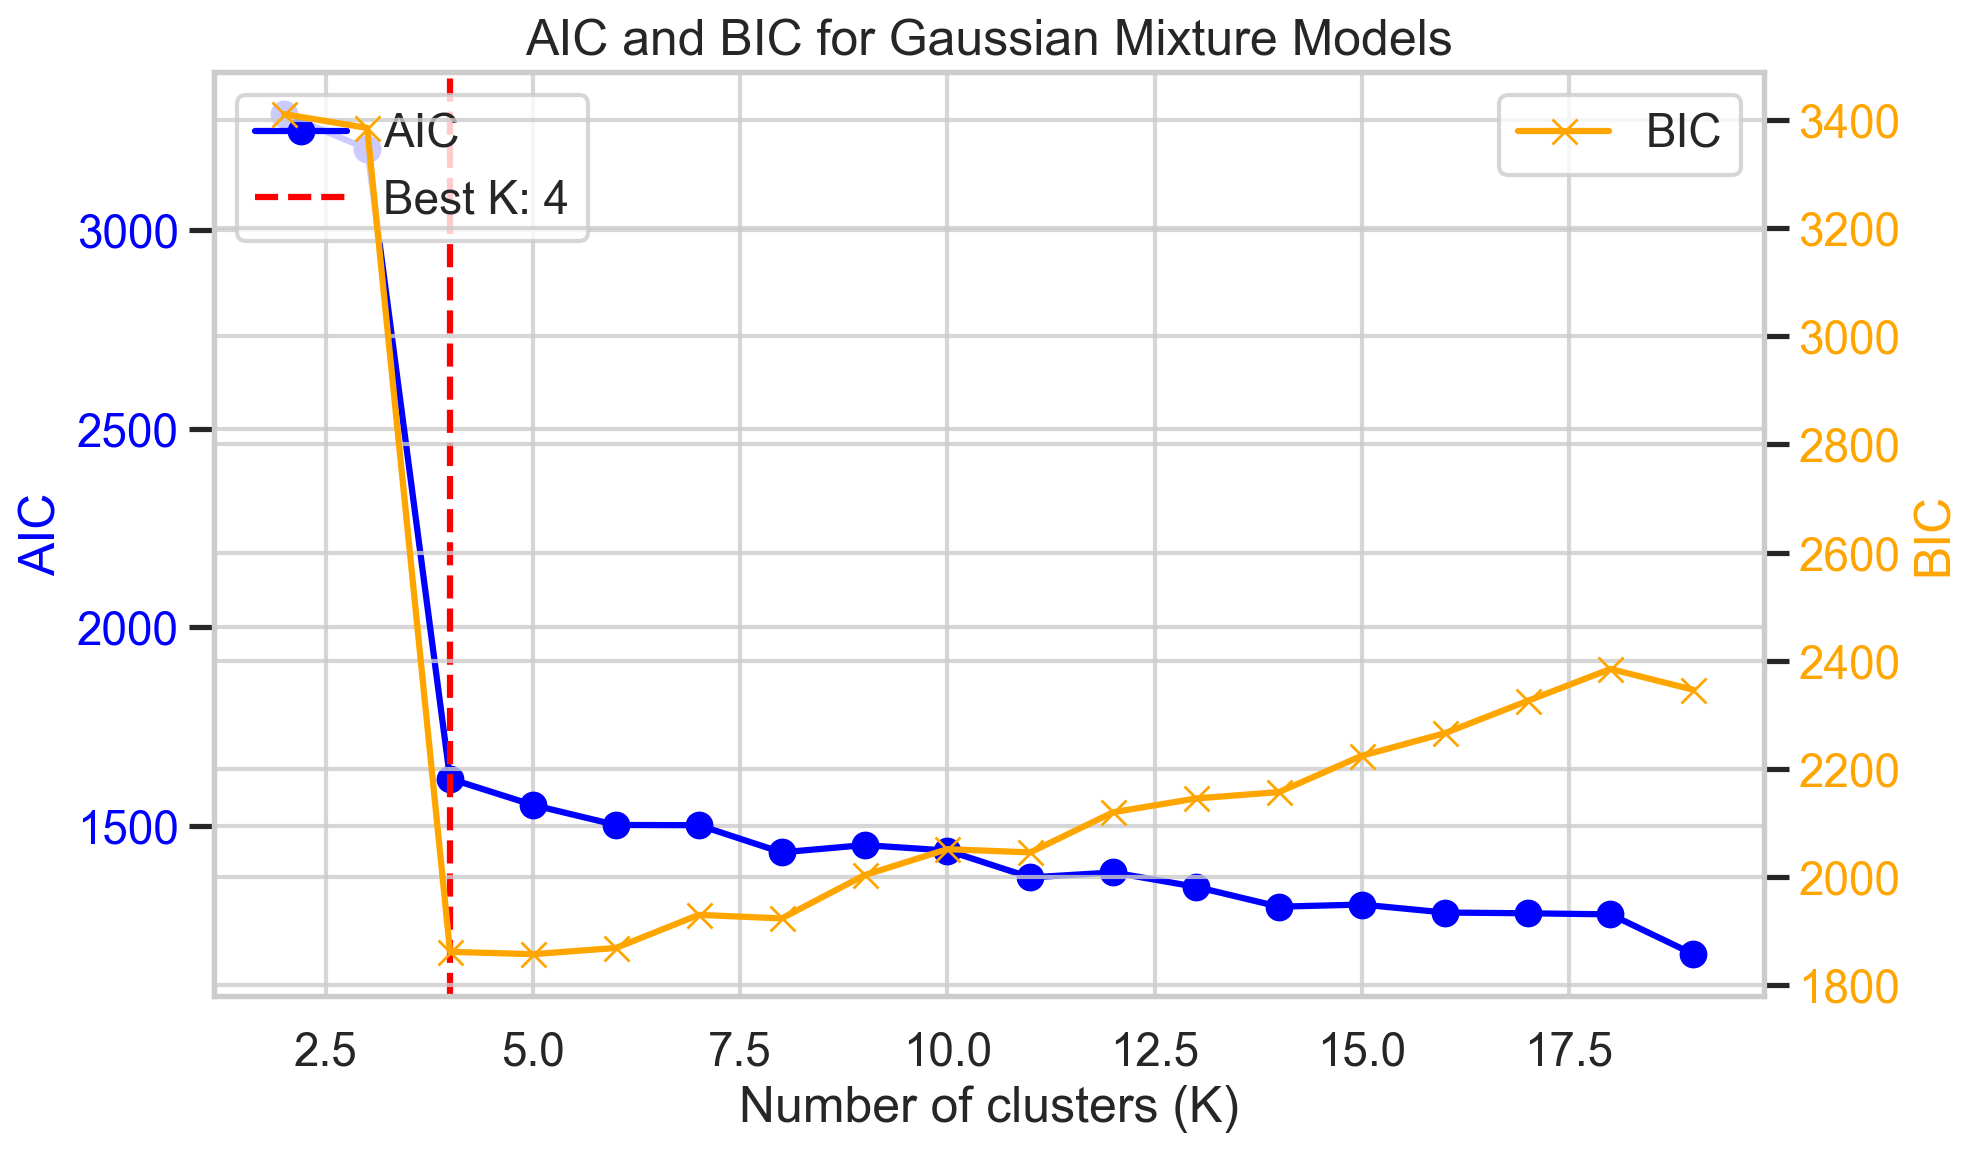

In [53]:
# plot the aic and bic
best_k = clustering_results["aic"].diff().idxmin()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(clustering_results.index, clustering_results["aic"], label="AIC",
            color="blue", marker="o")
ax2.plot(clustering_results.index, clustering_results["bic"], label="BIC",
            color="orange", marker="x")

ax1.axvline(best_k, color="red", linestyle="--", label=f"Best K: {best_k}")

ax1.set_xlabel("Number of clusters (K)")
ax1.set_ylabel("AIC", color="blue")
ax2.set_ylabel("BIC", color="orange")
ax1.tick_params(axis='y', labelcolor="blue")
ax2.tick_params(axis='y', labelcolor="orange")
ax1.set_title("AIC and BIC for Gaussian Mixture Models")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

In [54]:
# # best_k = 9
# # apply GMM with the best number of clusters
# gmm = GaussianMixture(
#     n_components=best_k,
#     random_state=42,
#     n_init=100,
#     covariance_type='full'  # Use full covariance for GMM
# )
# # Fit the model
# gmm.fit(X_scaled_df)

# clusters = features_df.copy()
# clusters["cluster"] = gmm.predict(X_scaled_df) + 1

# # map clusters to new labels based on size of the cluster (cluster 1 is the largest) {old: new}
# clusters_mapping = clusters["cluster"].value_counts().sort_values(ascending=False).index
# clusters_mapping = {old: new for new, old in enumerate(clusters_mapping, start=1)}
# clusters["cluster"] = clusters["cluster"].map(clusters_mapping)


# clusters[["probability_{}".format(clusters_mapping[i+1]) for i in range(best_k)]] = gmm.predict_proba(X_scaled_df)
# # get the centroids
# centroids = pd.DataFrame(gmm.means_, columns=X.columns)
# centroids["cluster"] = np.arange(1, best_k + 1)
# centroids["cluster"] = centroids["cluster"].map(clusters_mapping)  # map to new labels
# centroids = centroids.set_index("cluster")

In [60]:
# apply GMM with the best number of clusters

gmm = clustering_results.loc[best_k, "model"]

clusters = features_df.copy()
clusters[features] = fused_feats
clusters["cluster"] = gmm.predict(clusters[features]) + 1

# map clusters to new labels based on size of the cluster (cluster 1 is the largest) {old: new}
clusters_mapping = clusters["cluster"].value_counts().sort_values(ascending=False).index
clusters_mapping = {old: new for new, old in enumerate(clusters_mapping, start=1)}
clusters["cluster"] = clusters["cluster"].map(clusters_mapping)


clusters[["probability_{}".format(clusters_mapping[i+1]) for i in range(best_k)]] = gmm.predict_proba(features_df[features])
# get the centroids
centroids = pd.DataFrame(gmm.means_, columns=X.columns)
centroids["cluster"] = np.arange(1, best_k + 1)
centroids["cluster"] = centroids["cluster"].map(clusters_mapping)  # map to new labels
centroids = centroids.set_index("cluster")

/home/galkepler/Projects/neuroaging/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(
/home/galkepler/Projects/neuroaging/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(


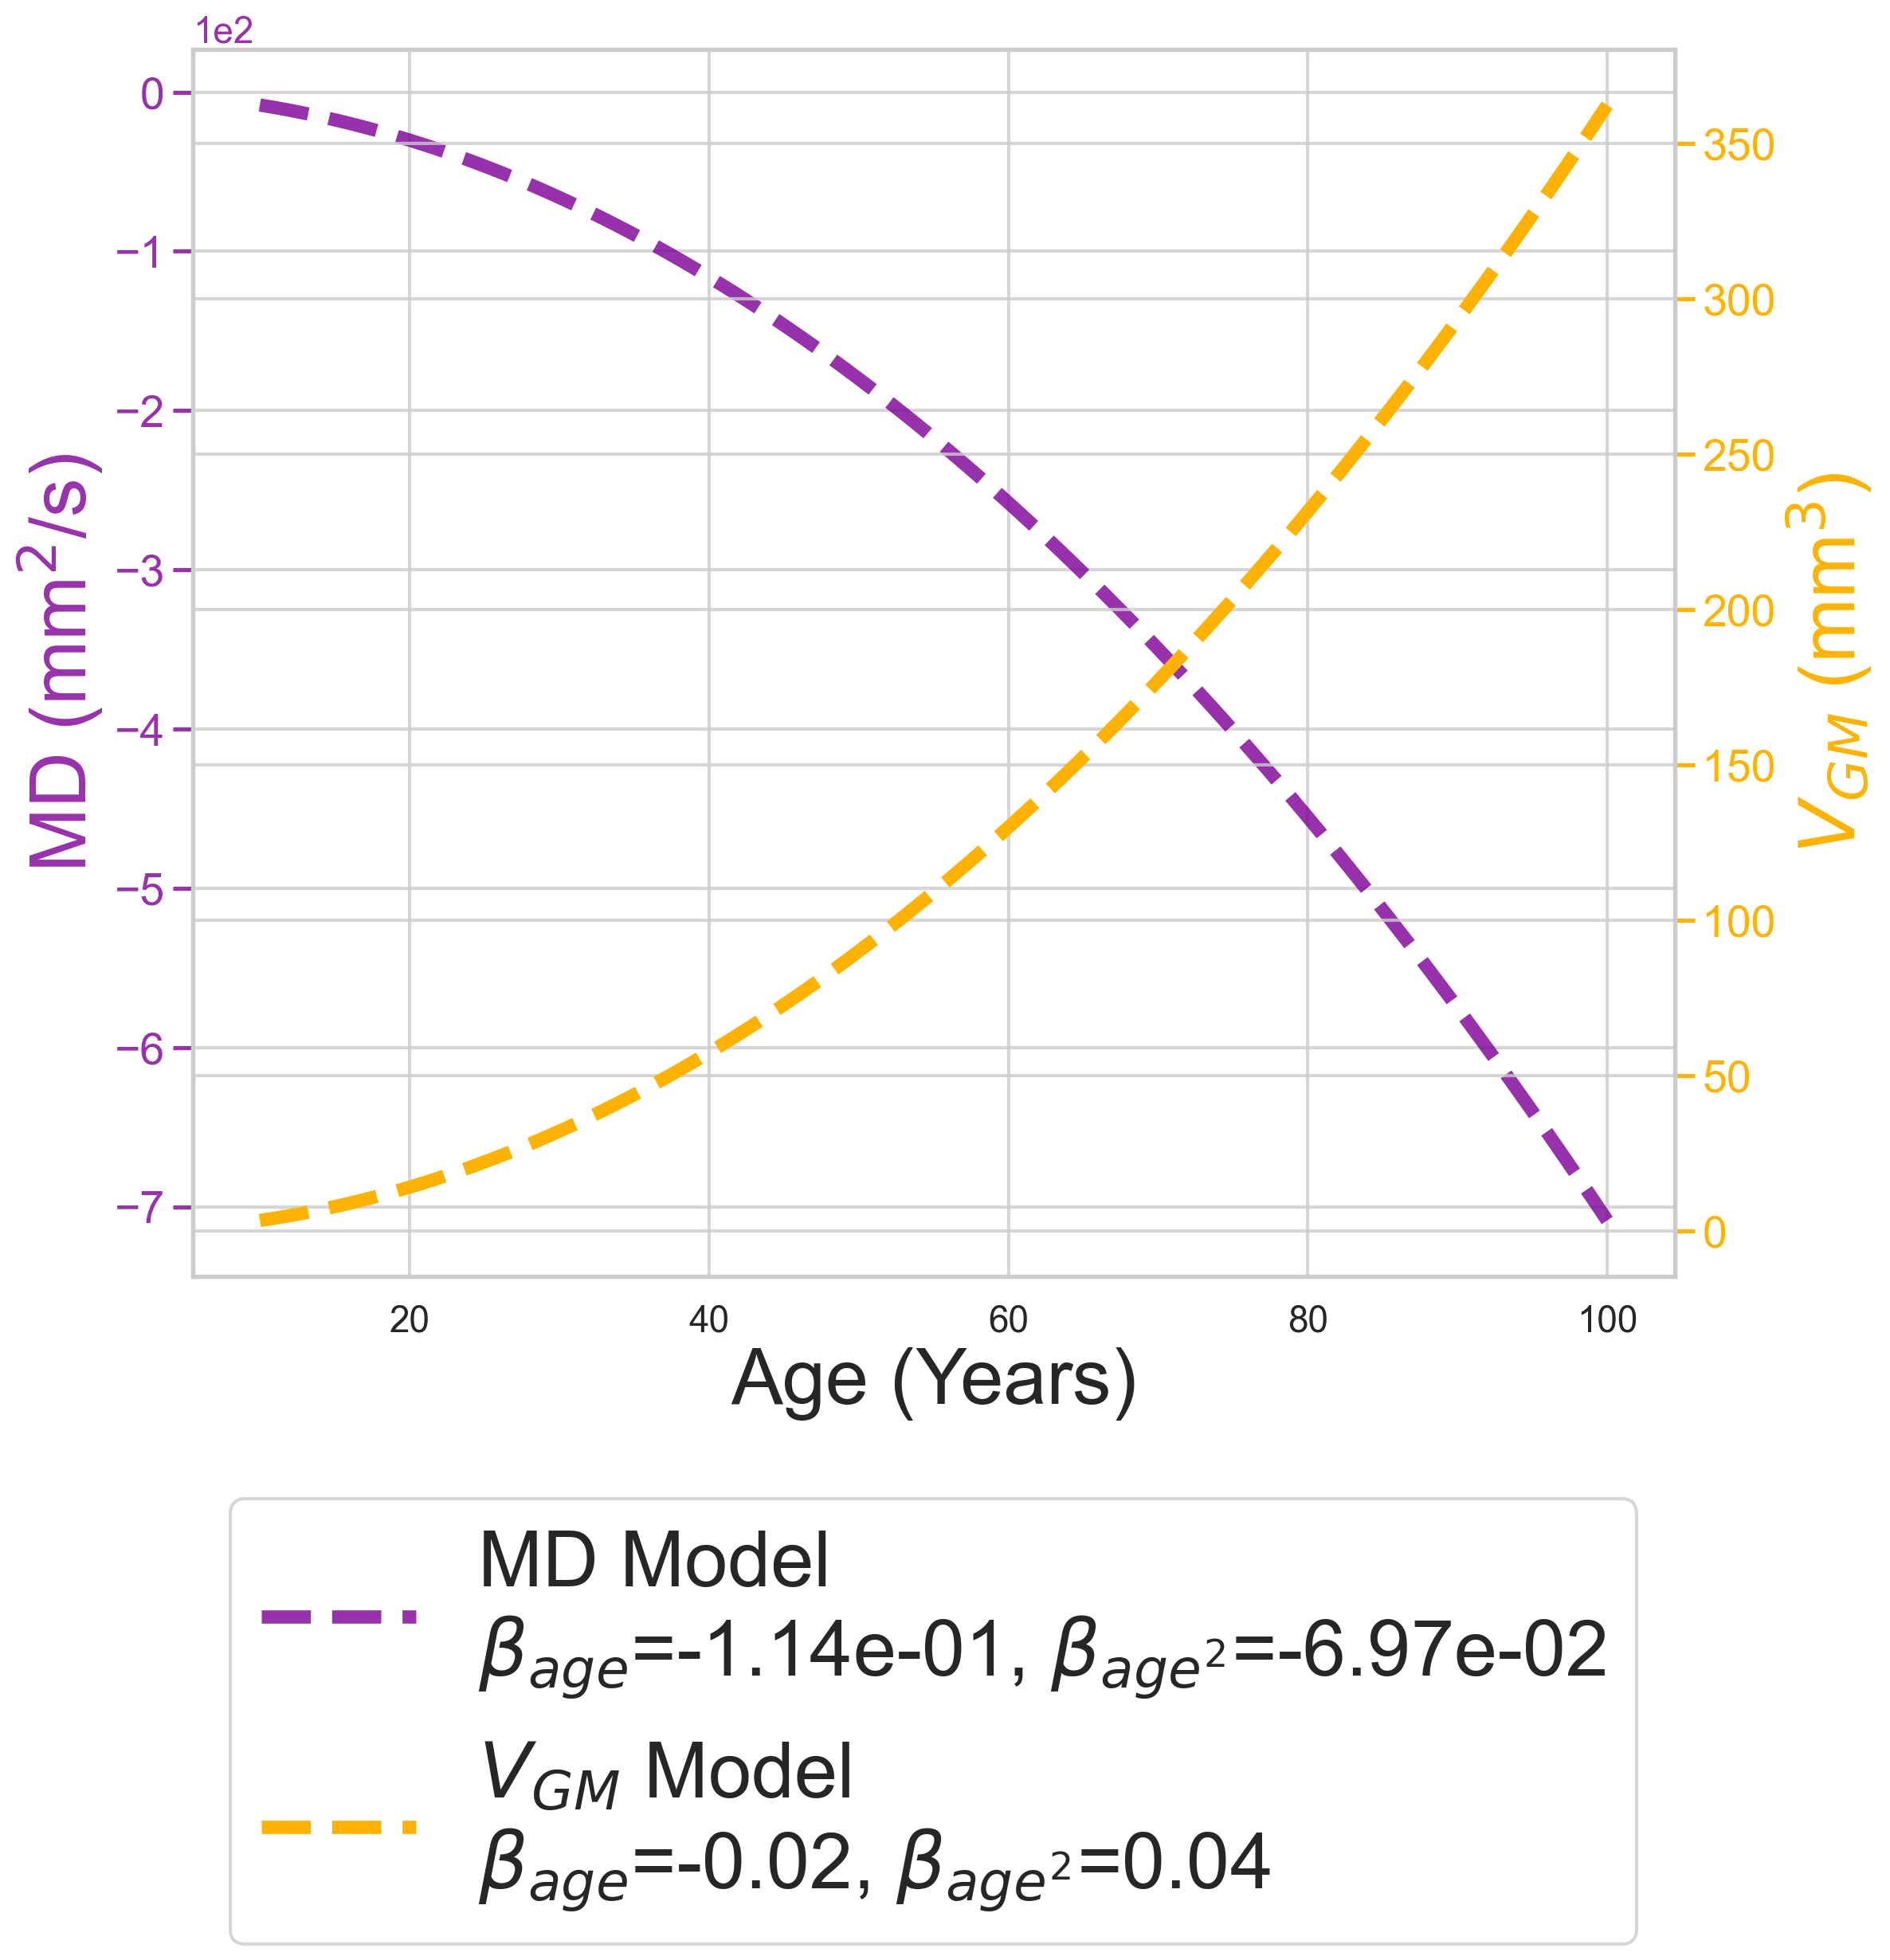

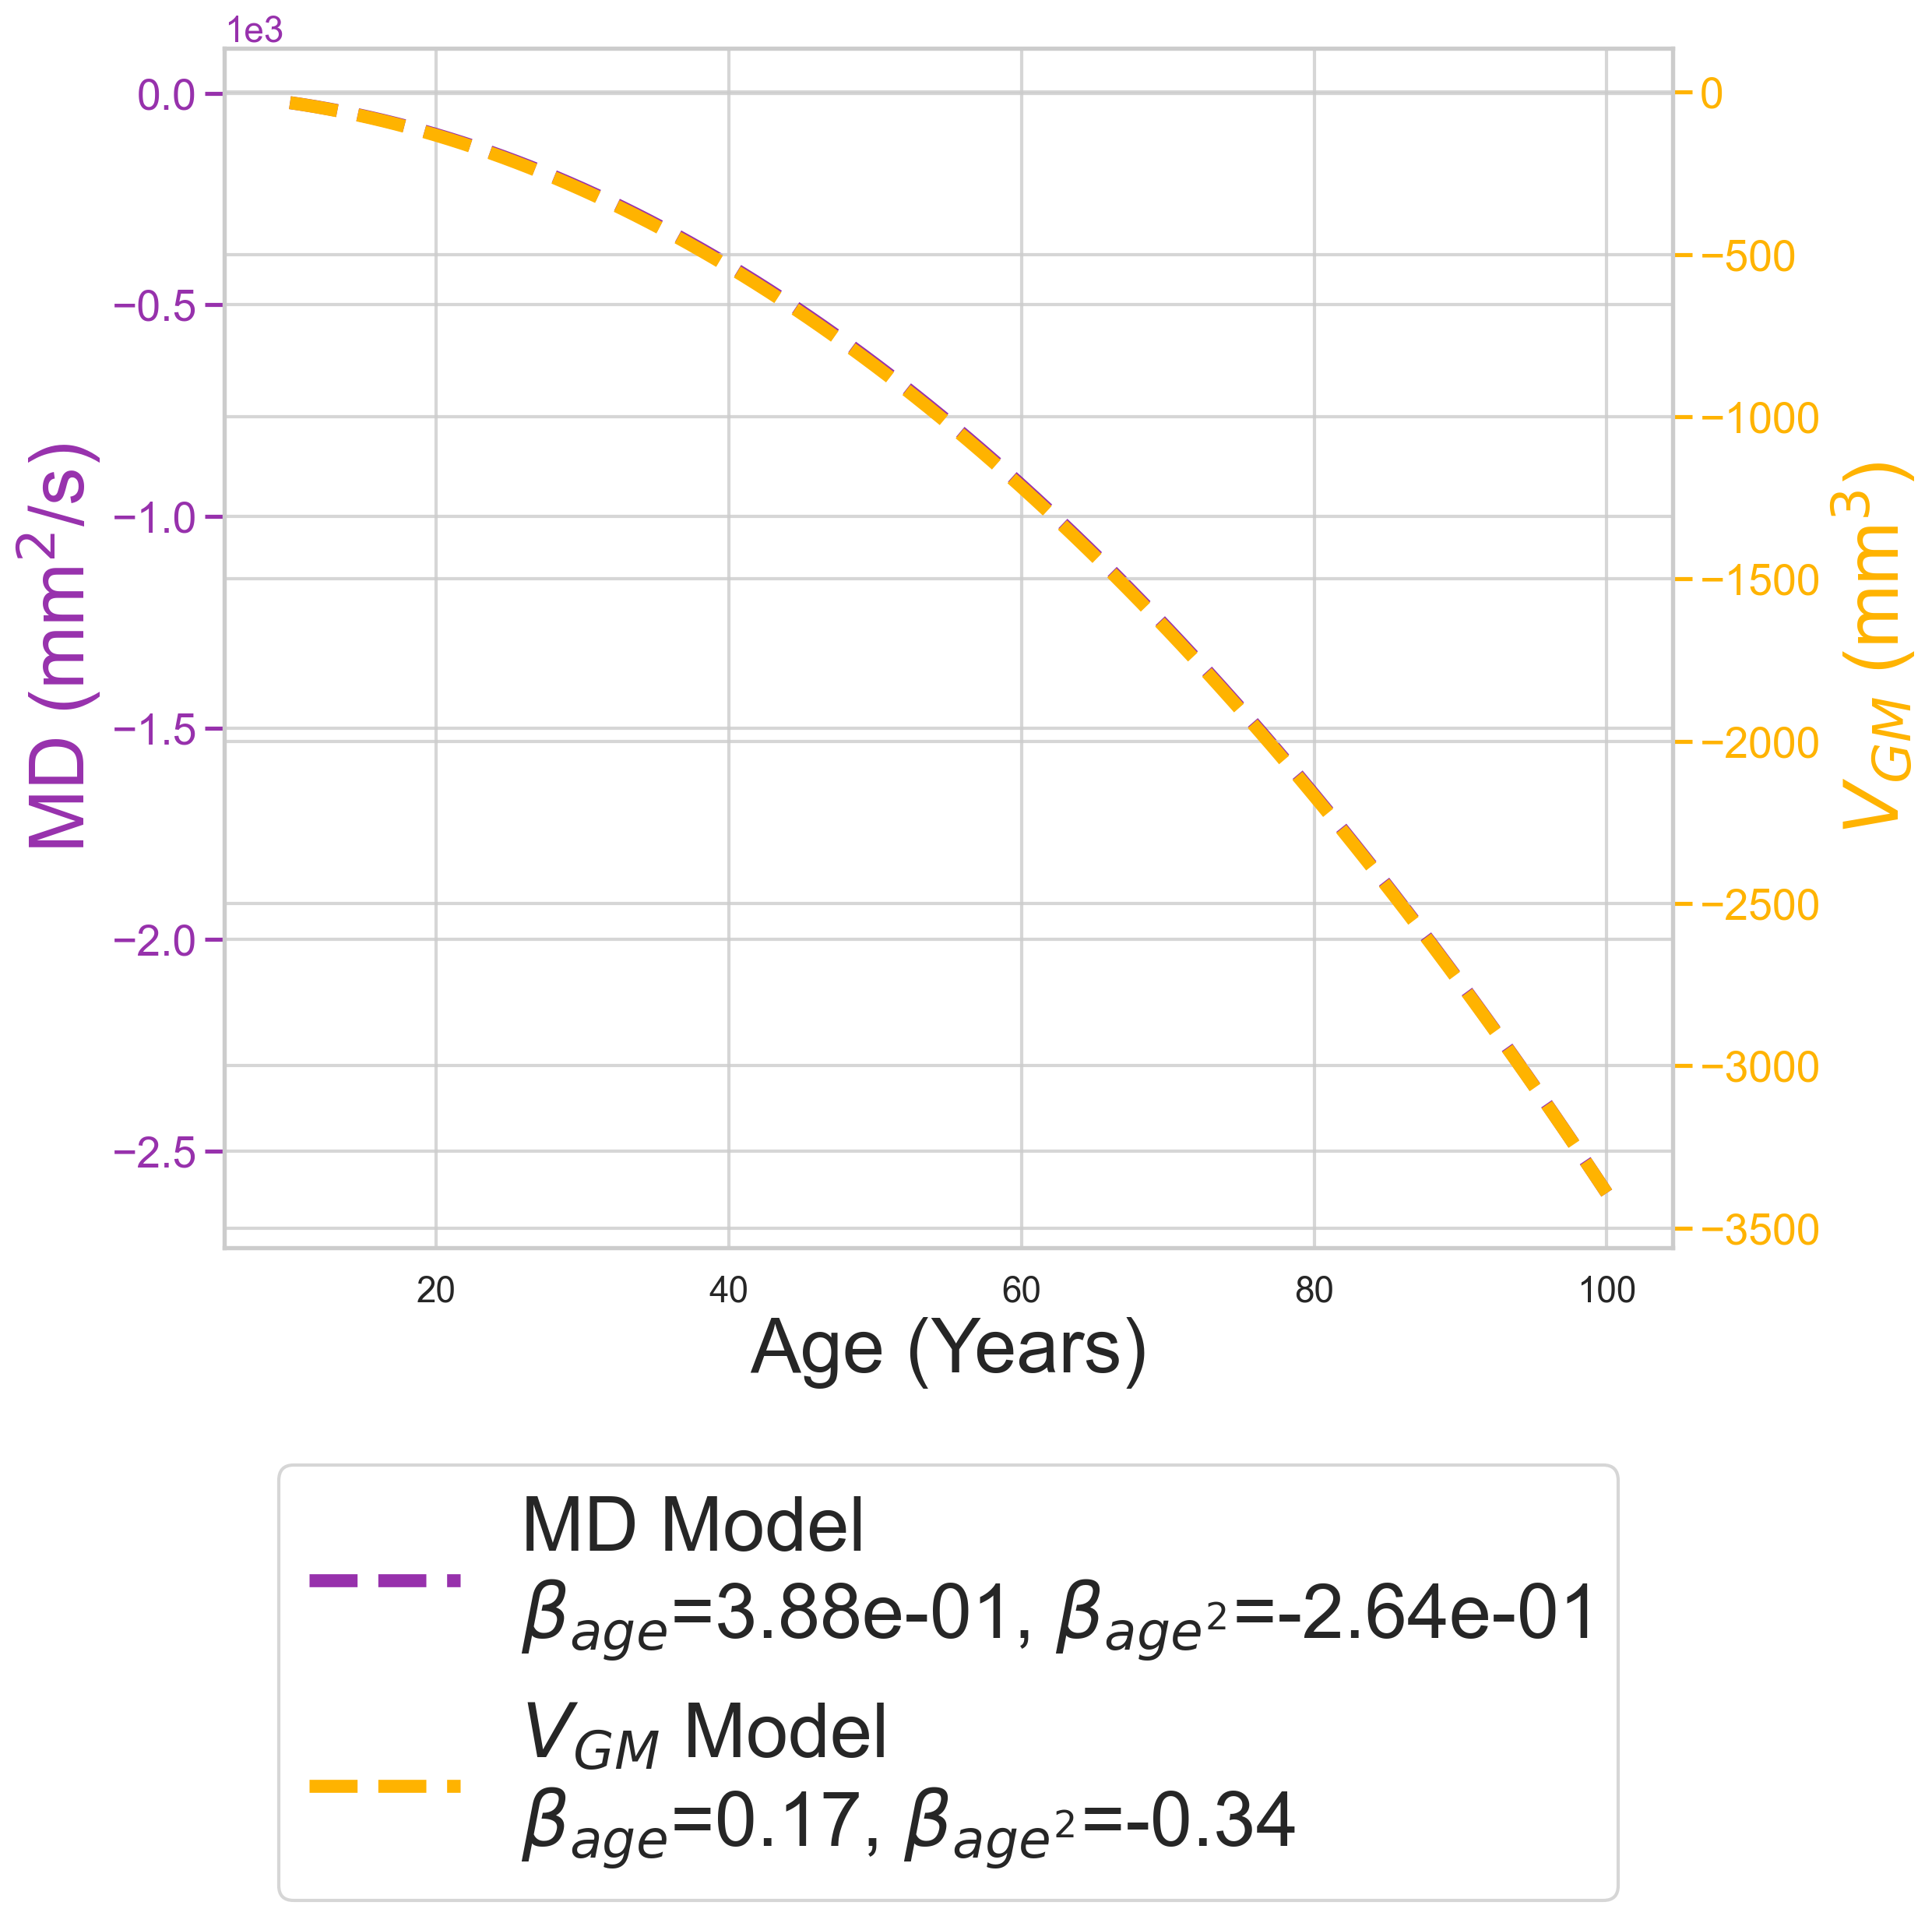

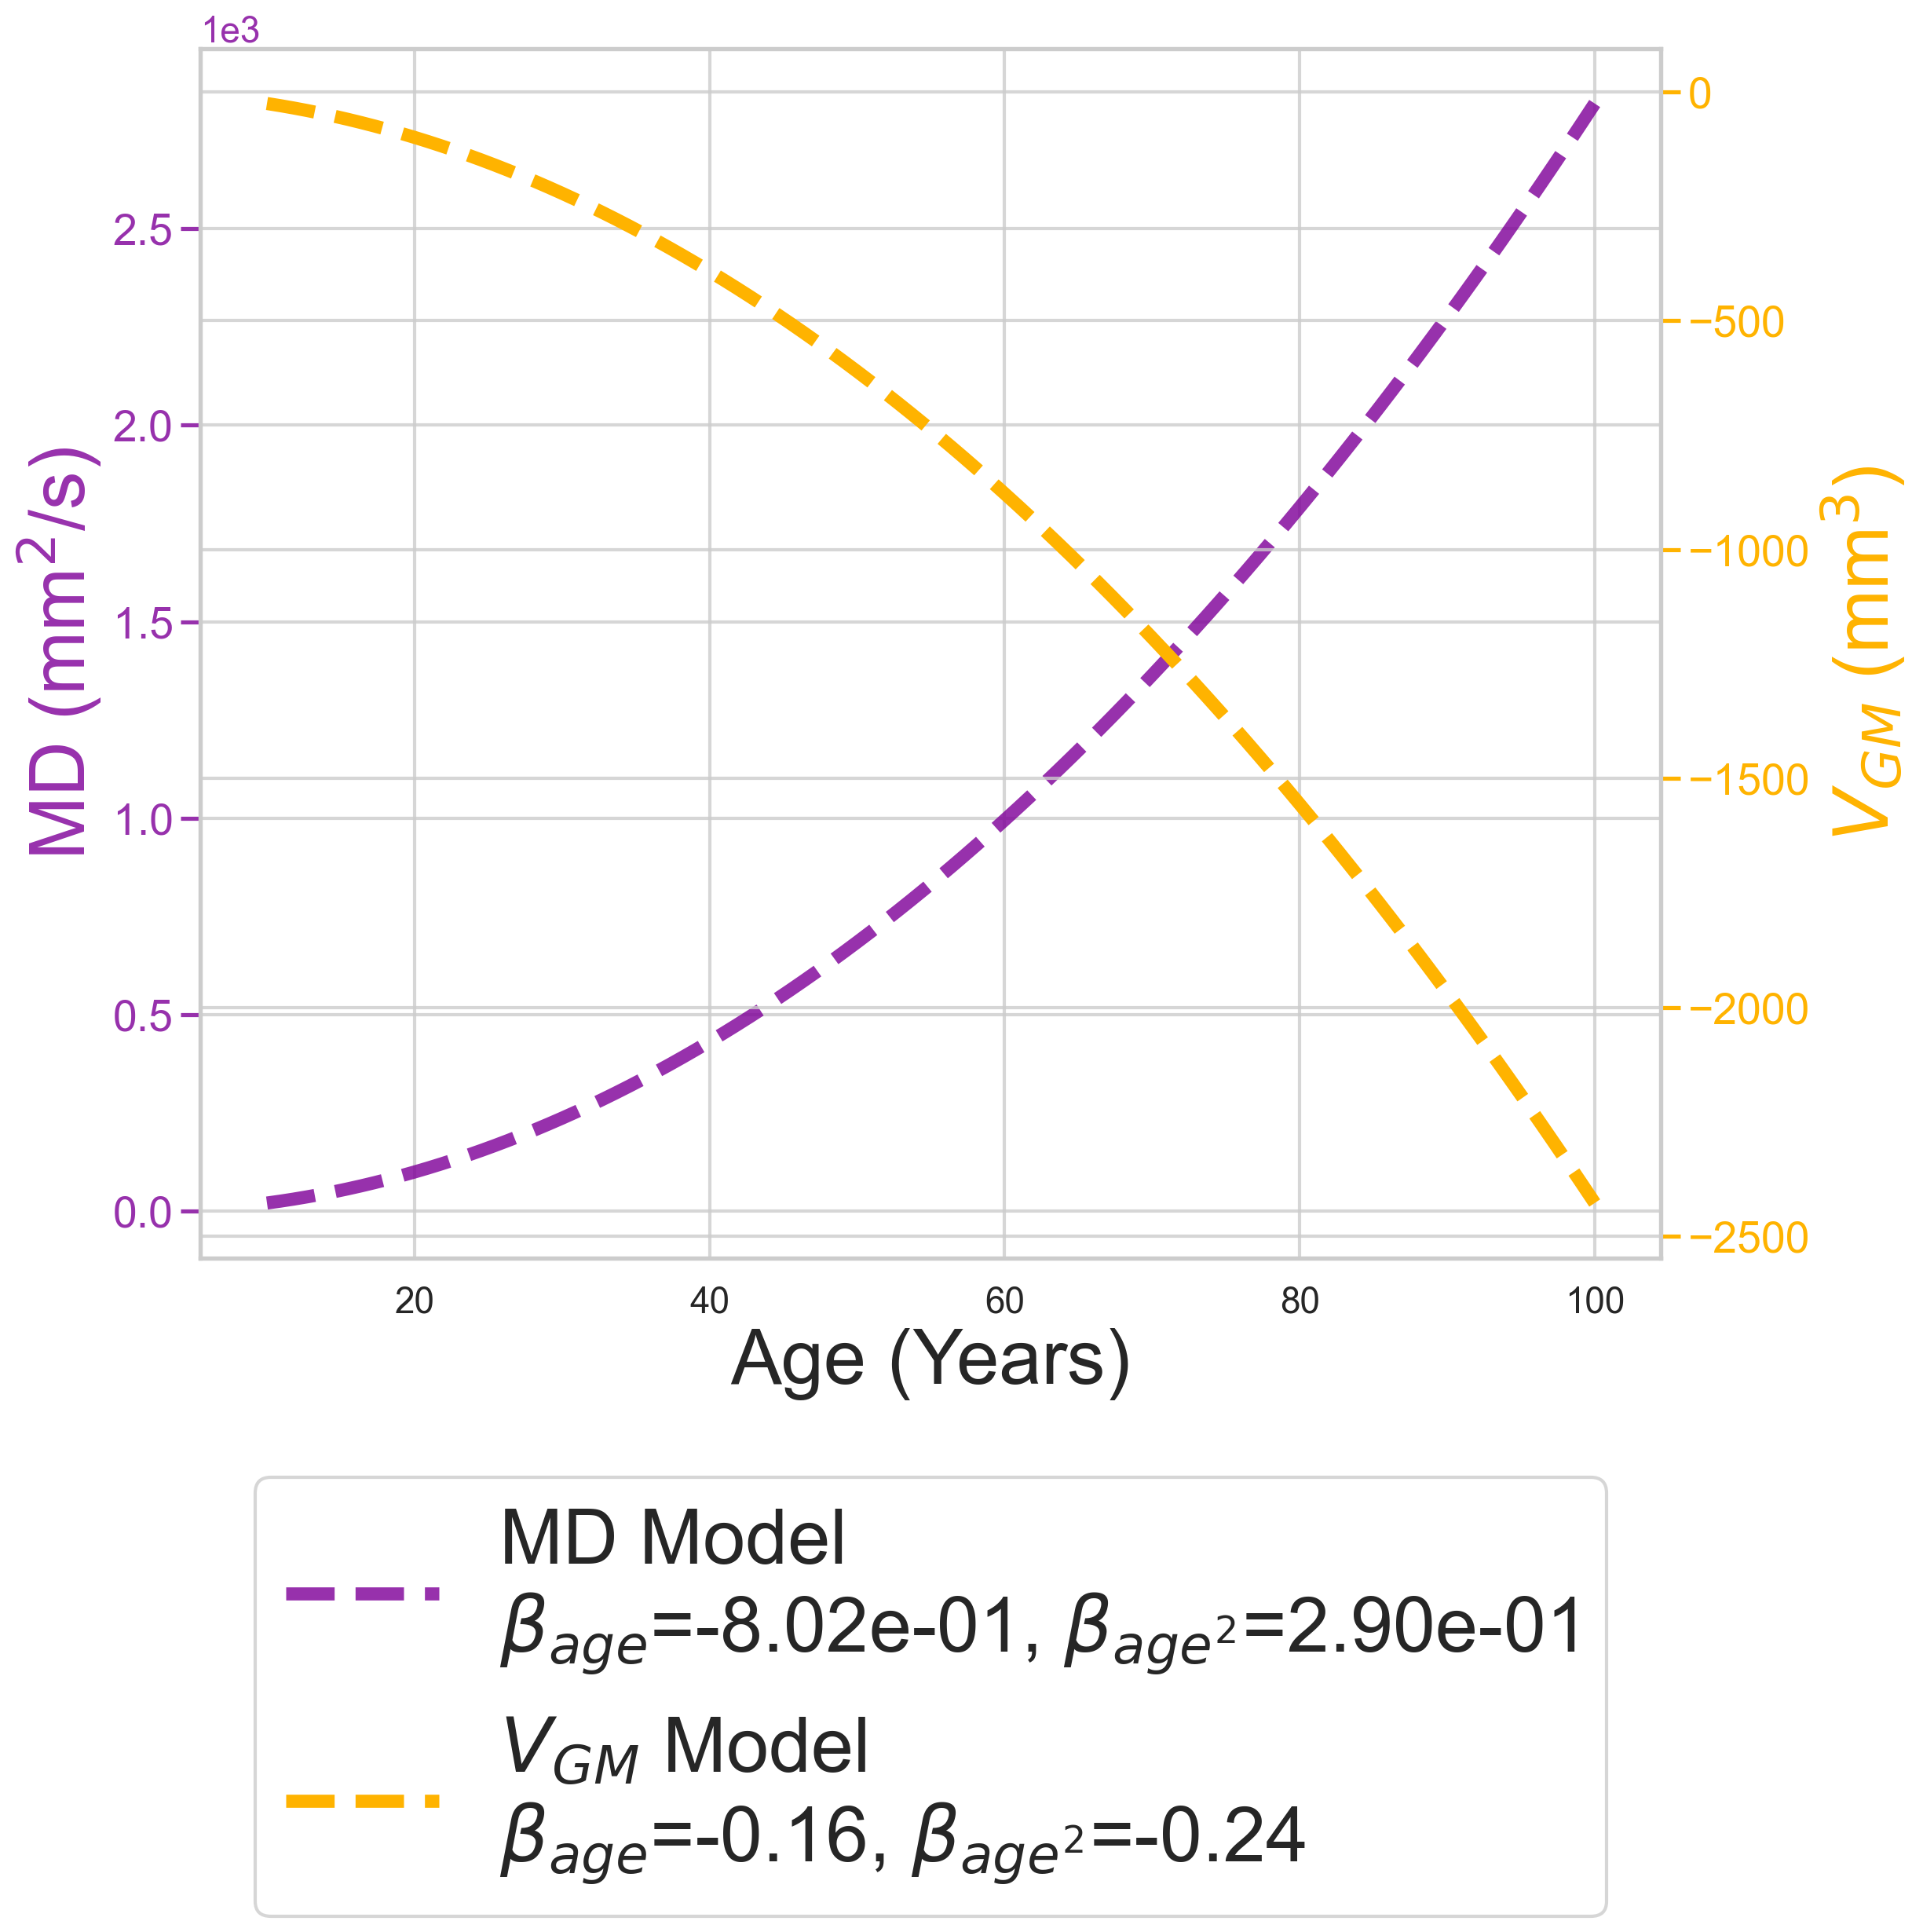

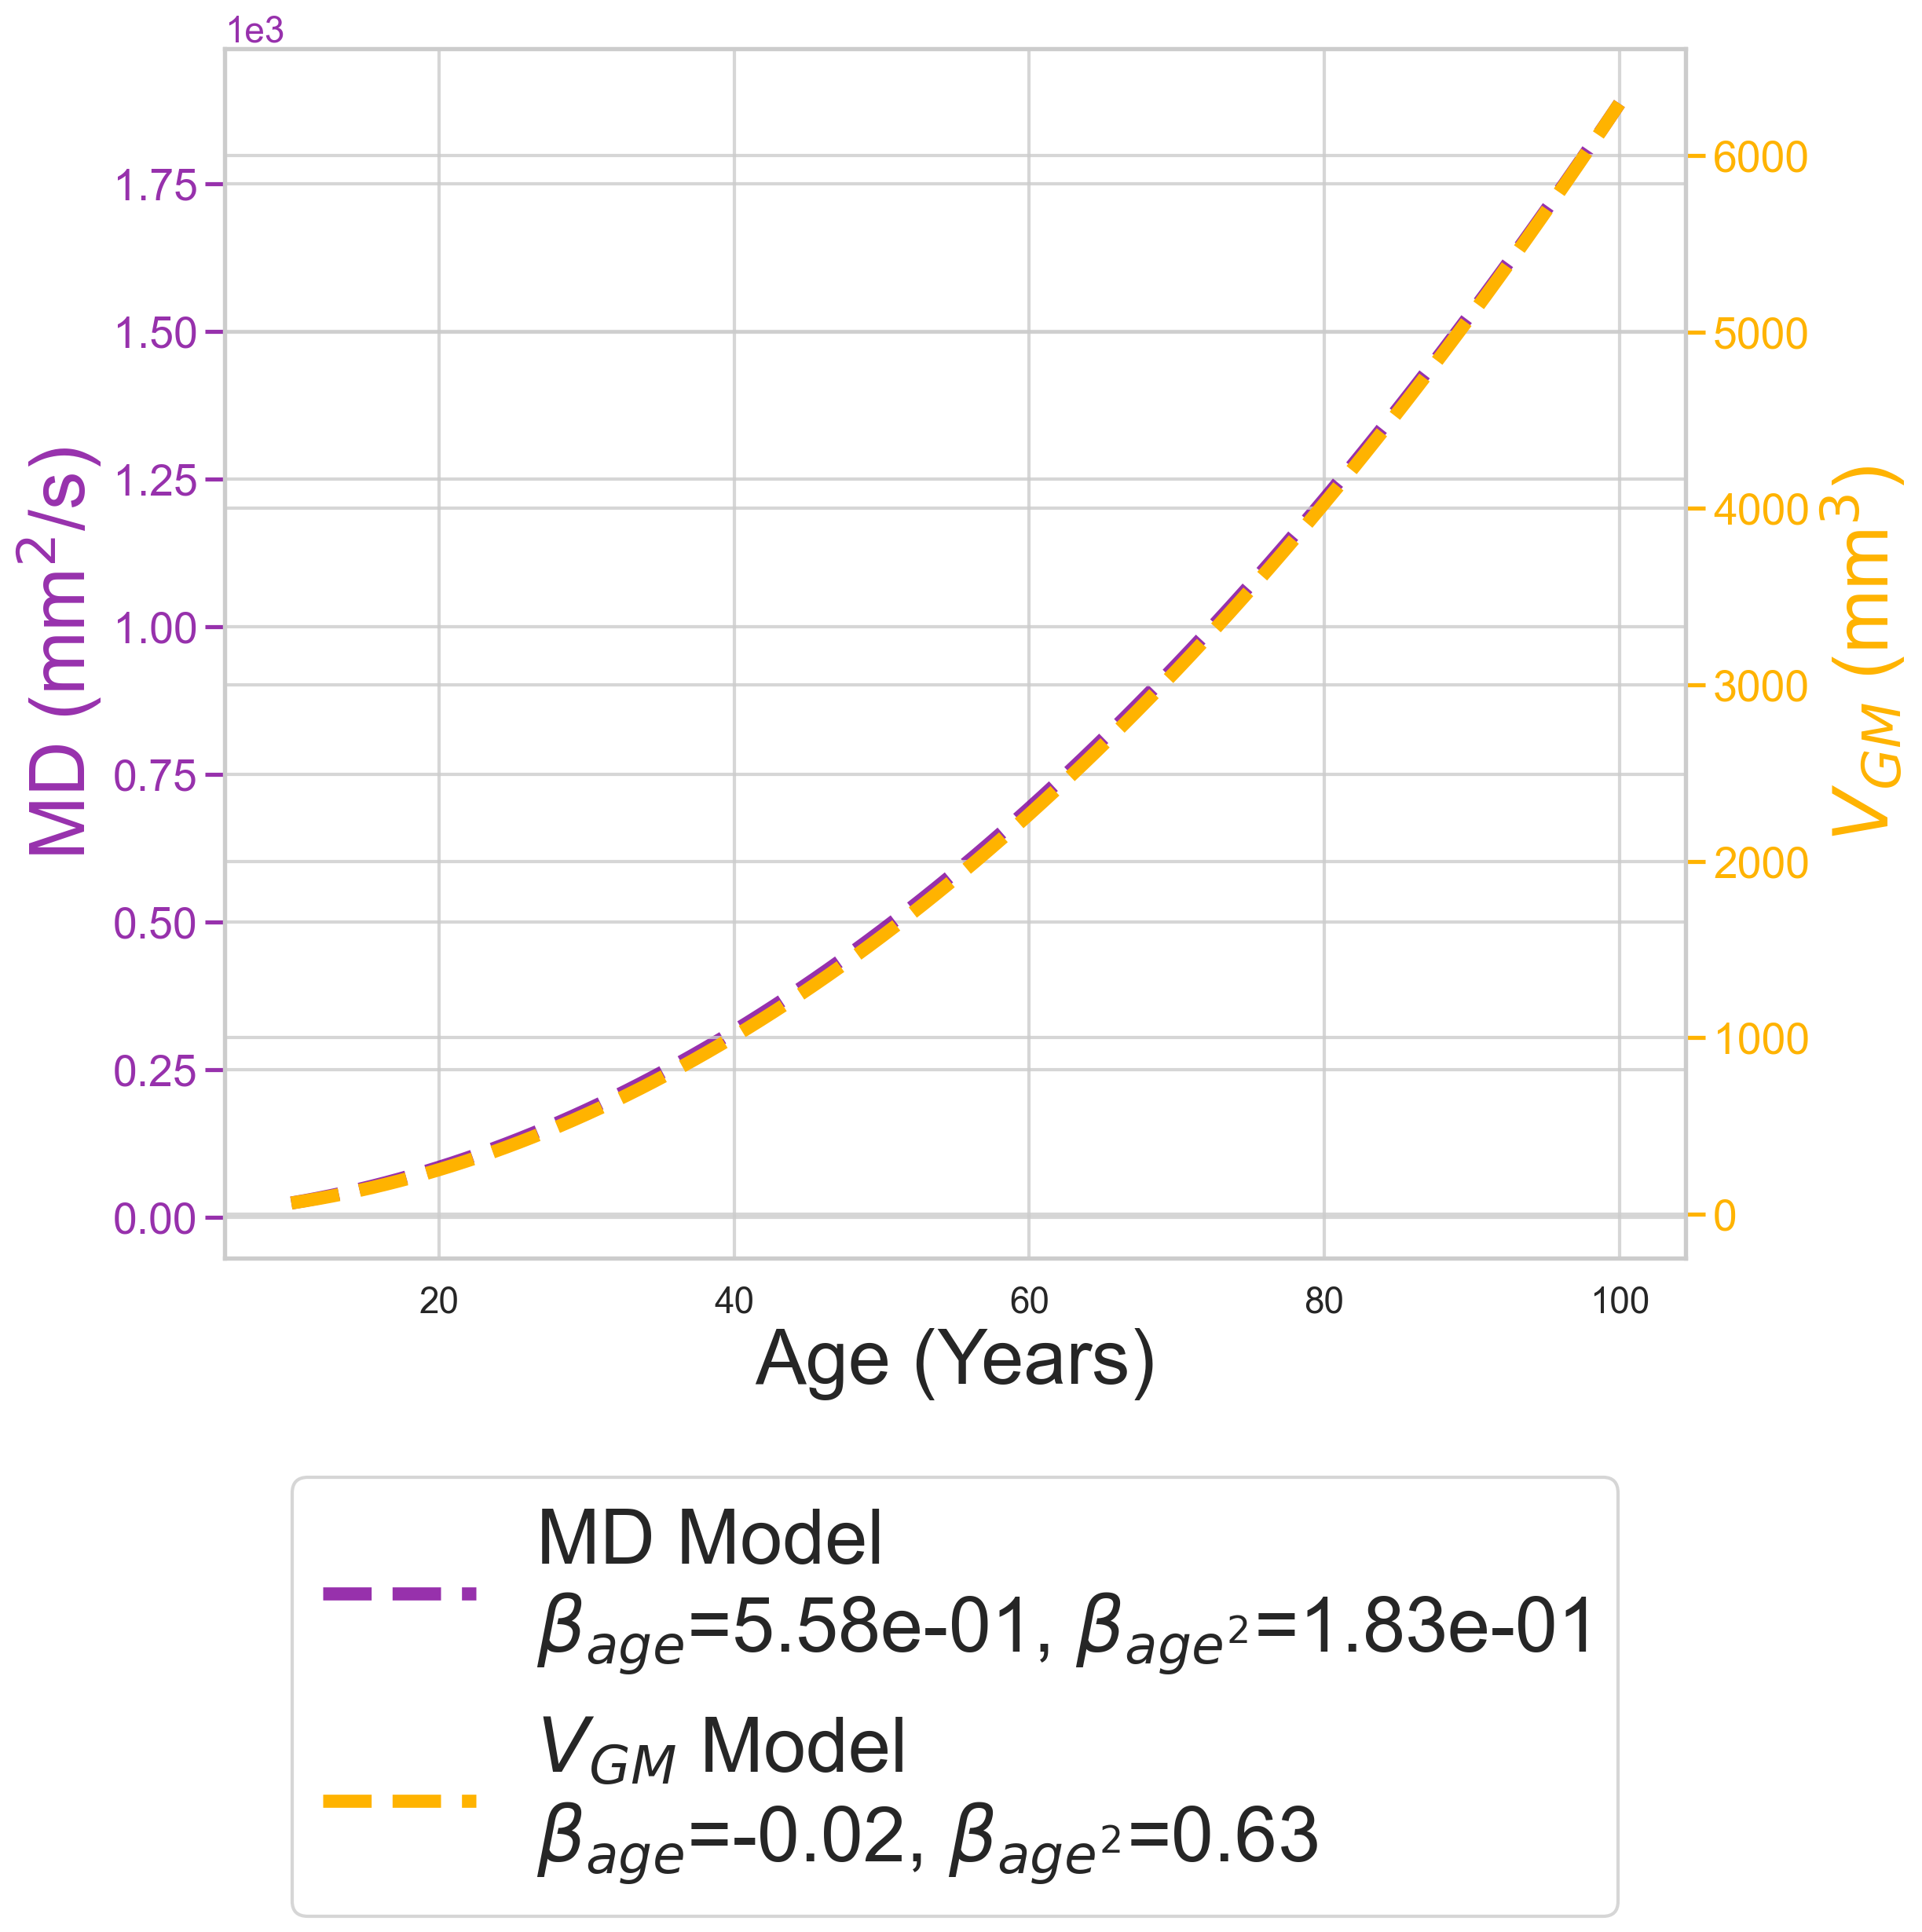

In [63]:
metrics_visualization = {
    "adc": "MD",
    "gm_vol": "$V_{GM}$",
}

ylims = {
    "adc": (-0.0002, 0.0002),
    "gm_vol": (-500, 500),
}

units = {
    "adc": "mm$^2$/s",
    "gm_vol": "mm$^3$",
}

# Choose the cluster ID to visualize (e.g., 0, 1, 2 based on your chosen_k)
# You can change this value to visualize different clusters
for cluster_id_to_visualize in range(1, best_k+1):
    if cluster_id_to_visualize not in centroids.index:
        print(
            f"Error: Cluster ID {cluster_id_to_visualize} not found. Please choose a valid ID from 0 to {best_k-1}."
        )
    else:
        # Get the representative coefficients for the selected cluster
        cluster_coeffs = centroids.loc[cluster_id_to_visualize]
        ages = np.linspace(10, 100, 100)  # From 20 to 90 years, 100 points
        fig, ax1 = plt.subplots(figsize=(12, 10))
        ax2 = ax1.twinx()

        lines = []
        labels = []

        for metric, c, ax in zip(metrics, [COL_WEIGHTED, COL_RAW], [ax1, ax2]):
            # Extract coefficients for the linear and quadratic models
            # interpcet = cluster_coeffs[f"{metric}_intercept"]
            interpcet = 0
            beta1 = cluster_coeffs.get(f"{metric}_beta1", 0)  # Default to 0 if not present
            beta2 = cluster_coeffs.get(f"{metric}_beta2", 0)  # Default to 0 if not present
            # interpcet = 0
            # beta1 = cluster_coeffs.get(f"{metric}_t_beta1", 0)  # Default to 0 if not present
            # beta2 = cluster_coeffs.get(f"{metric}_t_beta2", 0)  # Default to 0 if not present

            # Define a range of ages for visualization

            predicted_volume_quadratic = interpcet + beta1 * ages + beta2 * (ages**2)
            # predicted_volume_quadratic = StandardScaler().fit_transform(predicted_volume_quadratic.reshape(-1, 1)).flatten()

            label = f"{metrics_visualization[metric]} Model\n"
            if metric == "adc":
                label += "$\\beta_{{age}}$={:.2e}, $\\beta_{{age^2}}$={:.2e}".format(beta1, beta2)
            else:
                label += "$\\beta_{{age}}$={:.2f}, $\\beta_{{age^2}}$={:.2f}".format(
                    beta1, beta2
                )

            lines += ax.plot(
                ages,
                predicted_volume_quadratic,
                # label=f"{metrics_visualization[metric]} Model Trend\n$\\beta_1$={beta1:.2f}, $\\beta_2$={beta2:.2f}",
                label=label,
                color=c,
                linestyle="--",
                linewidth=6,
            )
            # ax.set_ylim(ylims[metric])
            labels.append(label)
            ax.set_xlabel("Age (Years)", fontsize=35)
            ax.set_ylabel(f"{metrics_visualization[metric]} ({units[metric]})", fontsize=35, color=c)
            ax.tick_params(axis='y', which='major', labelsize=20, color=c, labelcolor=c)
            if metric == "adc":
                # set ticks to scientific notation
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax.tick_params(axis='x', which='major', labelsize=20)

        # Plot the trends
        # plt.plot(ages, predicted_volume_quadratic, label="Quadratic Model Trend", color="red")
        # plt.title(f"Representative Aging Trend(s) for Cluster {cluster_id_to_visualize}")
        # plt.ylabel("Predicted Value")
        plt.grid(True)
        # set legend below the plot
        plt.legend(lines,labels,fontsize=35, loc="upper center", bbox_to_anchor=(0.5, -0.15))
        # ax.set_ylim(-3,3)
        plt.show()
        # savefig_nice(fig, OUTPUT_DIR / f"cluster_{cluster_id_to_visualize}_trend.png")
        # break

        # print(f"Linear Model: Volume = {lin_intercept:.2f} + {lin_beta1:.3f} * Age")
        # print(
        #     f"Quadratic Model: Volume = {quad_intercept:.2f} + {quad_beta1:.3f} * Age + {quad_beta2:.5f} * Age^2"
        # )

/tmp/ipykernel_1341150/1459870668.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


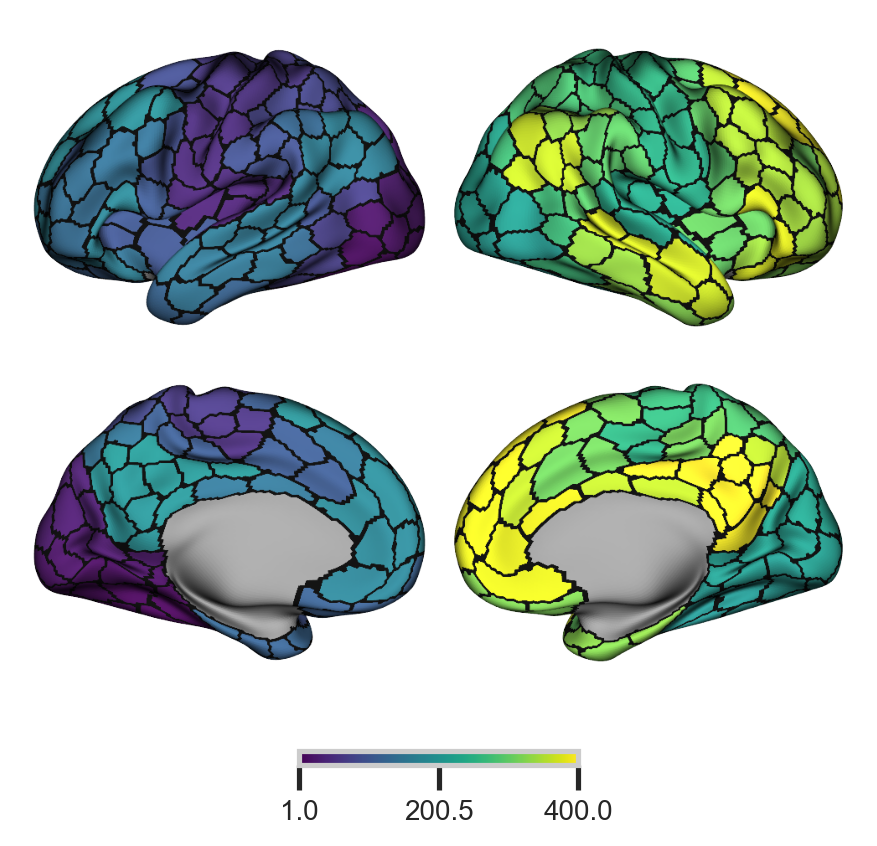

In [64]:
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from brainspace.datasets import load_parcellation

surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]
p = Plot(lh, rh)

# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")
p.add_layer({"left": lh_parc, "right": rh_parc}, cbar=True)

p.add_layer({"left": lh_parc, "right": rh_parc}, cmap="gray", as_outline=True, cbar=False)
fig = p.build()
fig.show()

In [65]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation


atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")

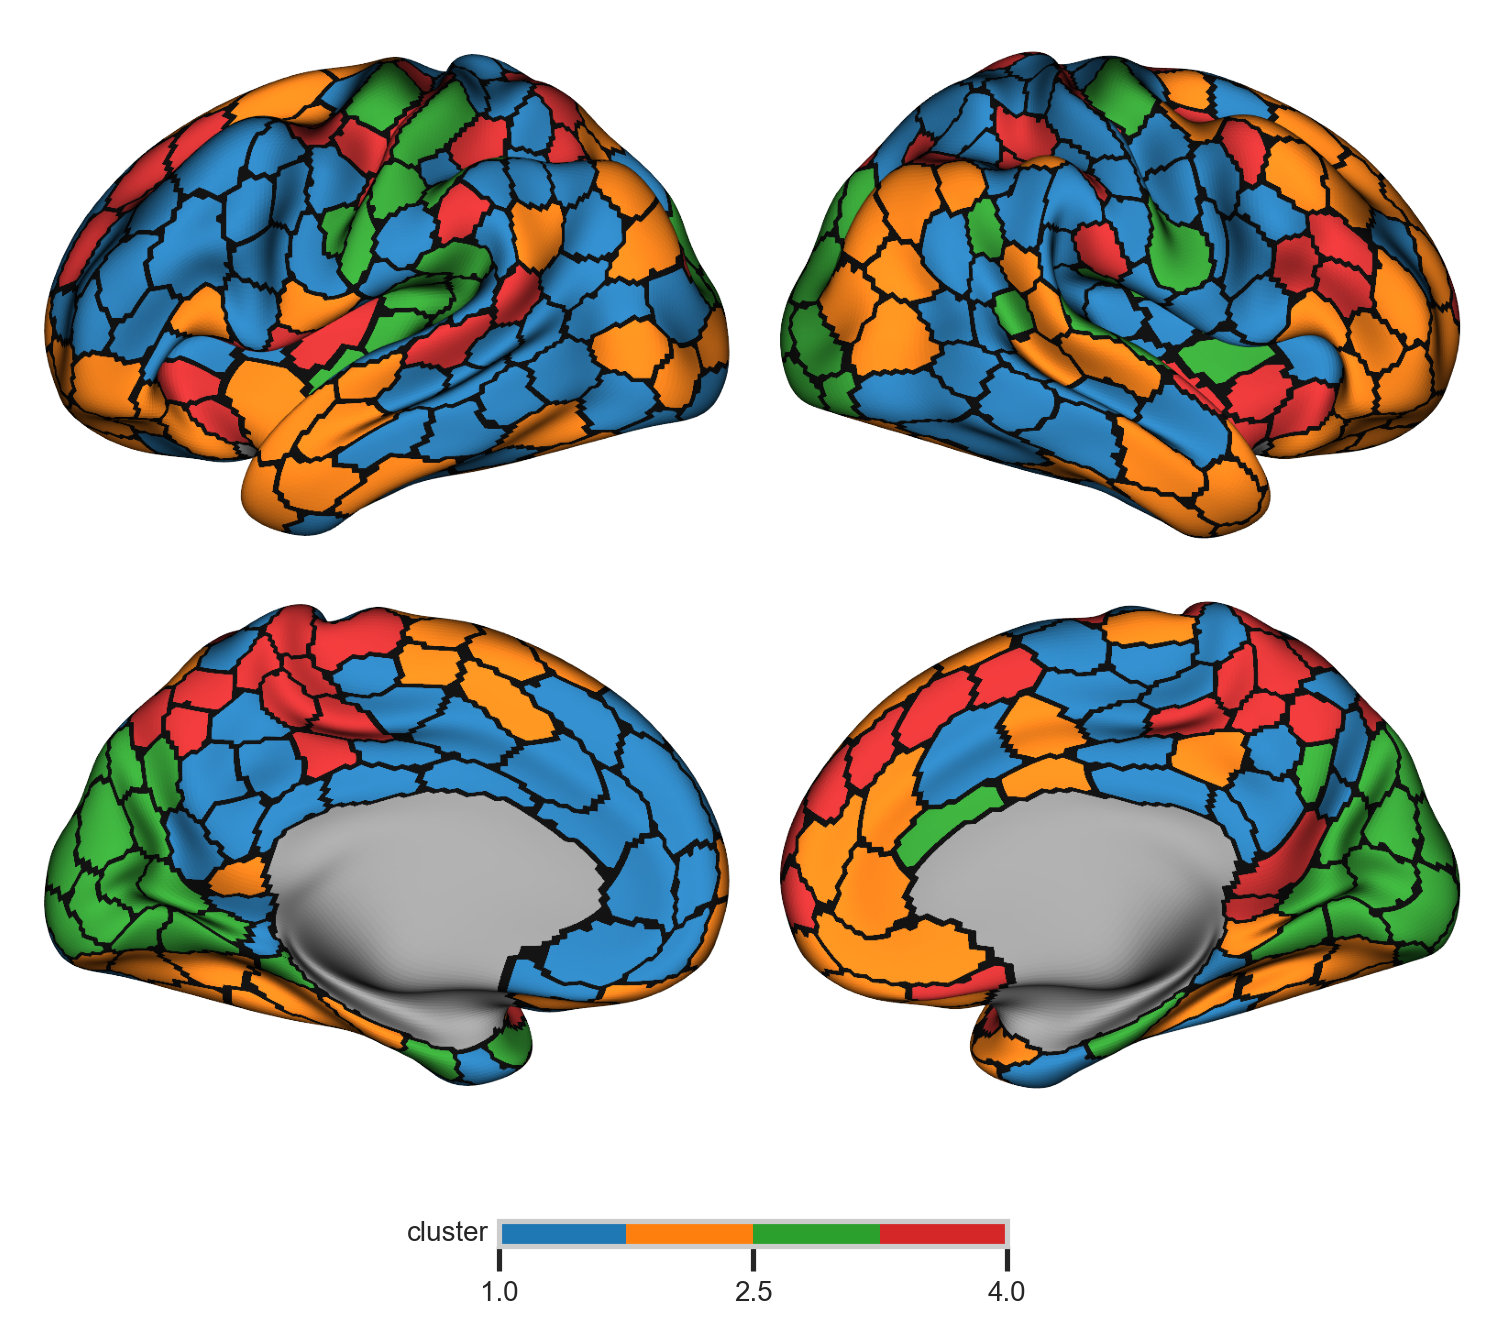

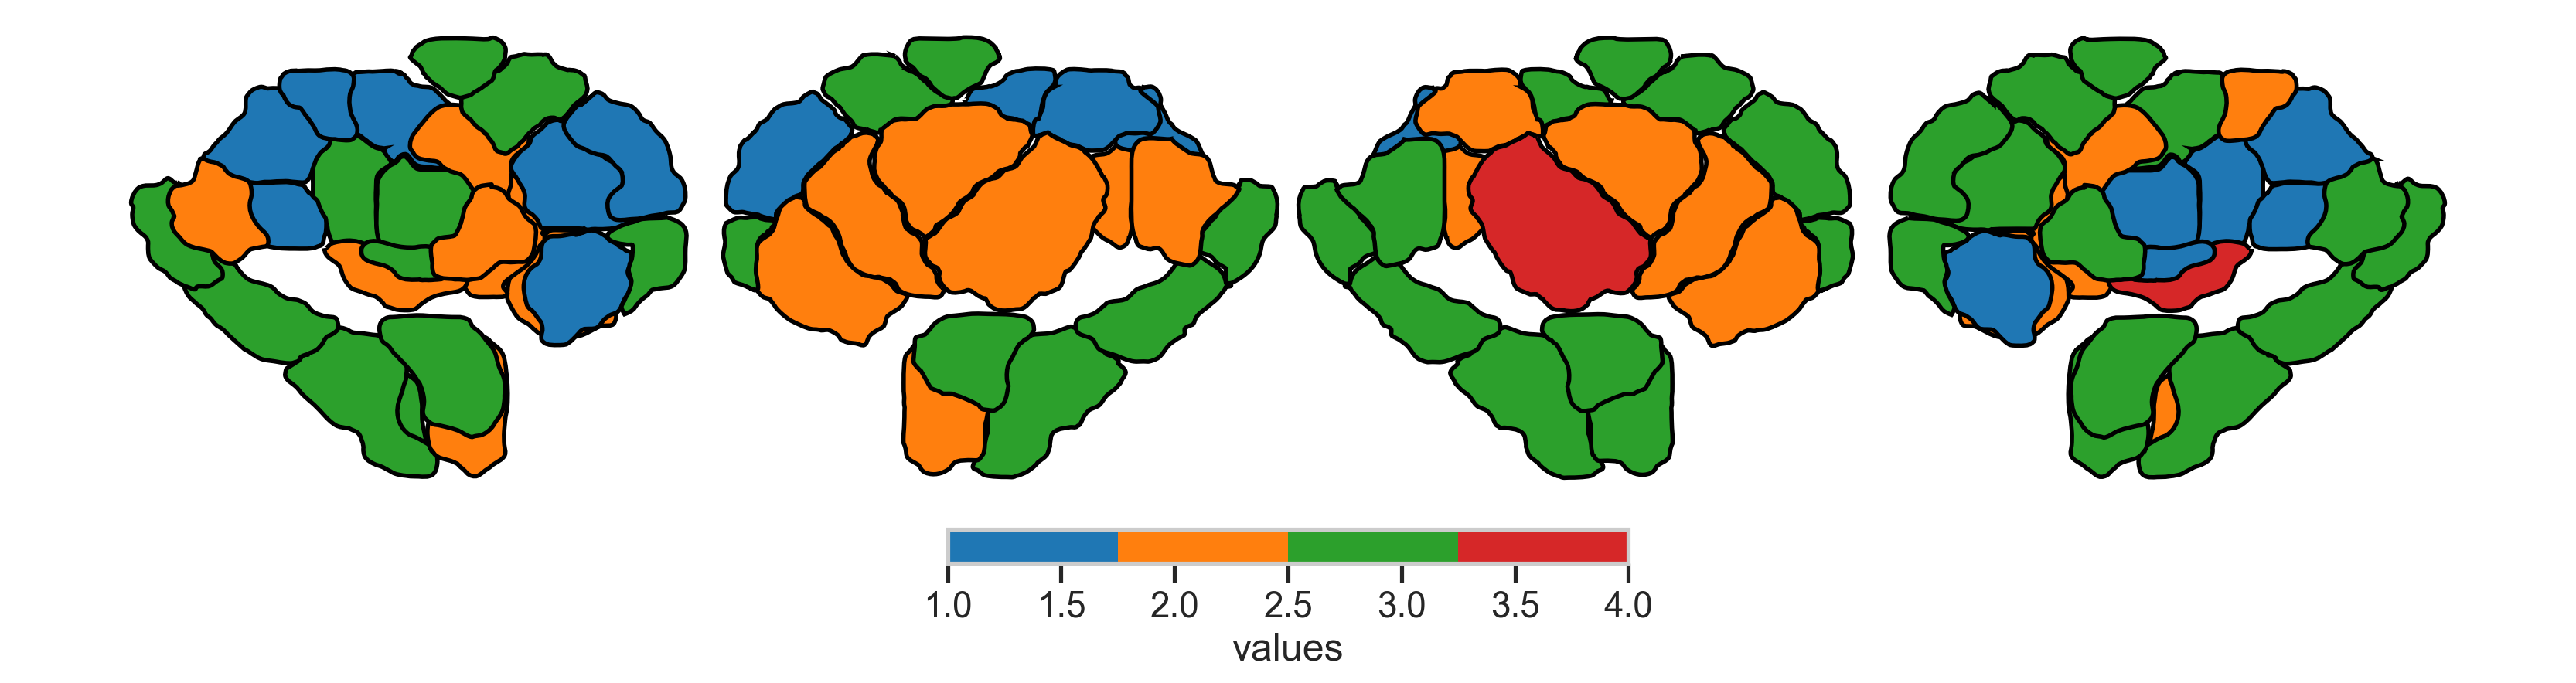

In [66]:
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------
p_threshold = 0.05
value_threshold = 0

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

# vis_df = w_compare
# value_column = "log(f)"
vis_df = clusters.copy()
# value_column = "r2_adj"
value_column = "cluster"
p_column = "p_corrected_beta2"

prob_threshold = 0.01

value_map_lh = {}  # New: separate map for left hemisphere
value_map_rh = {}  # New: separate map for right hemisphere

for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    # if (row[p_column] < p_threshold) and (np.abs(row[value_column]) > value_threshold):
    value = float(row[value_column])
    if "prob" in value_column and value < prob_threshold:
        value = np.nan
    # else:
    #     value = np.nan  # Set to NaN if not significant or below value_threshold
    if value_column == "log(f)":
        if vis_df.loc[i, "delta_AIC"] > -15:
            value = np.nan
        

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation


vmin = 1 if "prob" not in value_column else prob_threshold  # Set vmin to 1 for log(f) or 0 for probabilities
vmax = best_k if "prob" not in value_column else 1  # Set vmax to best_k for log(f) or 1 for probabilities

# create a colormap with categorical colors (the same number of colors as clusters)
clusters_cmap = cmap = mpl.colors.ListedColormap(sns.color_palette("tab10", best_k))
if "prob" not in value_column:
    cmap = clusters_cmap
else:
    # get cluster colors from clusters_cmap
    vis_cluster = int(value_column.split("_")[-1])  # e.g., "probability_1" → "1"
    # end color is the color of the cluster
    end_color = clusters_cmap.colors[vis_cluster - 1]  # -1 for zero-indexing
    # create a gradient from white to the cluster color
    cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "cluster_gradient",
        [COL_WHITE, end_color],
        N=256,  # Number of colors in the gradient
    )
# vmin = 0
# vmax = 1  # Assuming clusters are labeled from 0 to best_k-1
# cmap = "Purples"

# Corrected loop for plotting each hemisphere independently
# for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
#     ["left", "right"],  # The key for surfplot's dictionary
#     [lh, rh],  # The surface object for the current hemisphere
#     [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
#     [lh_parc, rh_parc],  # The parcellation for the current hemisphere
# ):
# ---------------------------------------------------------------------
# 5.  BUILD THE PLOT
# ---------------------------------------------------------------------
# pref_surf = {
#     "surf_lh": hemi_surf_data if hemi_key == "left" else None,
#     "surf_rh": hemi_surf_data if hemi_key == "right" else None,
# }

# views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]
p = Plot(
    lh,
    rh,
    # Unpack the surface dictionary
    # views=["medial", "lateral"],  # Show both medial and lateral for this hemi
    size=(800, 600),  # px; change as needed
    zoom=1.6,
    layout="grid",  # Horizontal layout for side-by-side views
    mirror_views=True,  # Set to False, as we are plotting one hemi at a time
)

# ---- main data layer -------------------------------------------------
# Pass only the data for the current hemisphere
# The dictionary now contains only one key-value pair for the current hemisphere
p.add_layer(
    {"left": data_lh_mapped, "right": data_rh_mapped},
#     # cmap="Purples",
    cmap=cmap,
#     # cmap="coolwarm",
    color_range=(vmin, vmax),  # Use symmetric range
#     # norm=norm,  # Apply the symmetric normalization
    cbar_label=value_column,
    cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
)
# # ---- outline layer ---------------------------------------------------
p.add_layer({"left": lh_parc, "right": rh_parc}, cmap="gray", as_outline=True, cbar=False)

fig = p.build(
    # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
)  # Added cbar_kws for better cbar display
# # save figure
savefig_nice(fig, OUTPUT_DIR.resolve() / f"{value_column}.png", dpi=400)


from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


# for hemi in ["L", "R"]:

fig = plot_subcortical_data(
    subcort_df,
    atlas="Melbourne_S3",
    show_legend=True,
    hemisphere="both",
    cmap=cmap,
    # cmap=cmap,
    line_color="black",
    line_thickness=2,
    vmin=vmin,
    vmax=vmax,
    show_figure=False,
)

    # save figure
savefig_nice(fig, OUTPUT_DIR / f"subcort_{value_column}.png", dpi=400)

In [173]:
# vmin = 1
# vmax = best_k  # Assuming clusters are labeled from 0 to best_k-1

# # create a colormap with categorical colors (the same number of colors as clusters)
# cmap = mpl.colors.ListedColormap(sns.color_palette("tab10", n_colors=best_k))
# # vmin = 0
# # vmax = 1  # Assuming clusters are labeled from 0 to best_k-1
# # cmap = "Purples"

# # Corrected loop for plotting each hemisphere independently
# for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
#     ["left", "right"],  # The key for surfplot's dictionary
#     [lh, rh],  # The surface object for the current hemisphere
#     [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
#     [lh_parc, rh_parc],  # The parcellation for the current hemisphere
# ):
#     # ---------------------------------------------------------------------
#     # 5.  BUILD THE PLOT
#     # ---------------------------------------------------------------------
#     pref_surf = {
#         "surf_lh": hemi_surf_data if hemi_key == "left" else None,
#         "surf_rh": hemi_surf_data if hemi_key == "right" else None,
#     }

#     views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]
#     p = Plot(
#         **pref_surf,  # Unpack the surface dictionary
#         views=views,  # Show both medial and lateral for this hemi
#         size=(800, 300),  # px; change as needed
#         zoom=1.6,
#         # layout="row",  # For a single hemisphere, row is fine
#         mirror_views=False,  # Set to False, as we are plotting one hemi at a time
#     )

#     # ---- main data layer -------------------------------------------------
#     # Pass only the data for the current hemisphere
#     # The dictionary now contains only one key-value pair for the current hemisphere
#     p.add_layer(
#         {hemi_key: mapped_data},
#         # cmap="Purples",
#         cmap=cmap,
#         # cmap="coolwarm",
#         color_range=(vmin, vmax),  # Use symmetric range
#         # norm=norm,  # Apply the symmetric normalization
#         cbar_label=value_column,
#         cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
#     )
#     # ---- outline layer ---------------------------------------------------
#     p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

#     fig = p.build(
#         # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
#     )  # Added cbar_kws for better cbar display
#     # save figure
#     # savefig_nice(fig, OUTPUT_DIR.resolve() / f"fig2_{metric}_{hemi_key}_{value_column}.png", dpi=400)

In [174]:
# from subcortex_visualization.plotting import plot_subcortical_data

# subcort_df = pd.DataFrame(value_map_subcortex)
# if "schaefer" in ATLAS:
#     subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


# for hemi in ["L", "R"]:

#     fig = plot_subcortical_data(
#         subcort_df,
#         atlas="Melbourne_S3",
#         show_legend=True,
#         hemisphere=hemi,
#         cmap=cmap,
#         # cmap=cmap,
#         line_color="black",
#         line_thickness=2,
#         vmin=vmin,
#         vmax=vmax,
#         show_figure=False,
#     )

#     # save figure
#     # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)

In [175]:
example_rois = {
    413: {"name": "R. Putamen", "component": "Basal Ganglia"},
    447: {"name": "L. Amygdala", "component": "Limbic System"},
    168: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    179: {"name": "L. PFC", "component": "Prefrontal Cortex"},
    50: {"name": "L. Postcentral", "component": "Somatomotor"},
    258: {"name": "R. Precentral", "component": "Somatomotor"},
    405: {"name": "R. Hippocampus", "component": "Limbic System"},
    234: {"name": "Insula", "component": "Insular Cortex"},
    263: {"name": "L. Precentral", "component": "Somatomotor"},
    312: {"name": "Precuneus", "component": "Parietal Cortex"},
    267: {"name": "R. Precentral", "component": "Somatomotor"},
    67: {"name": "L. Precentral", "component": "Somatomotor"},
}

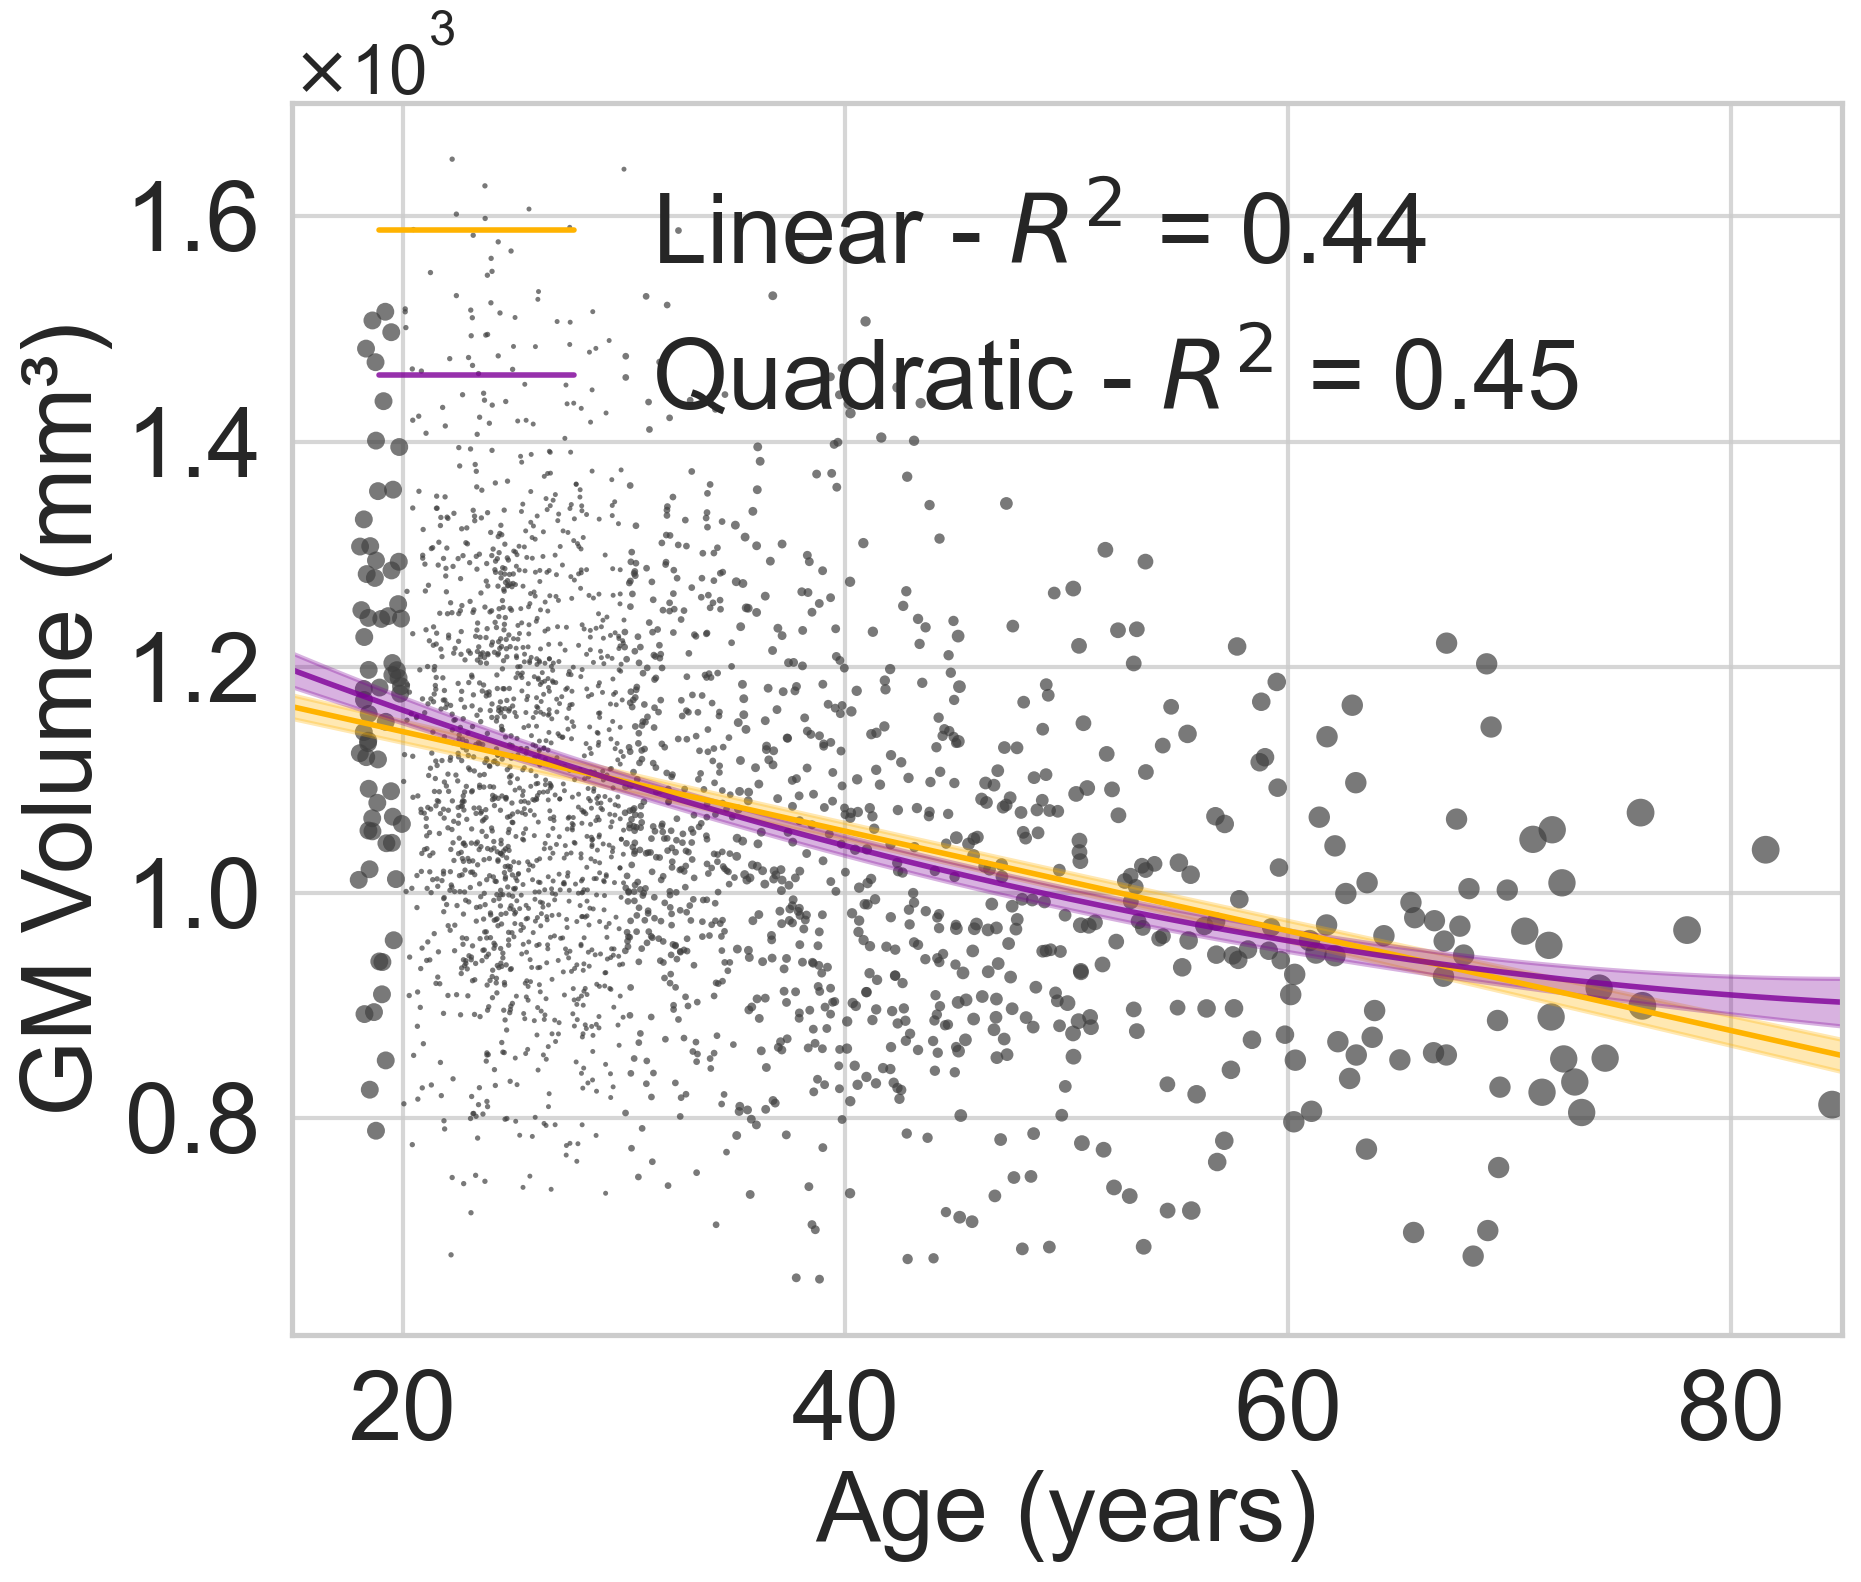

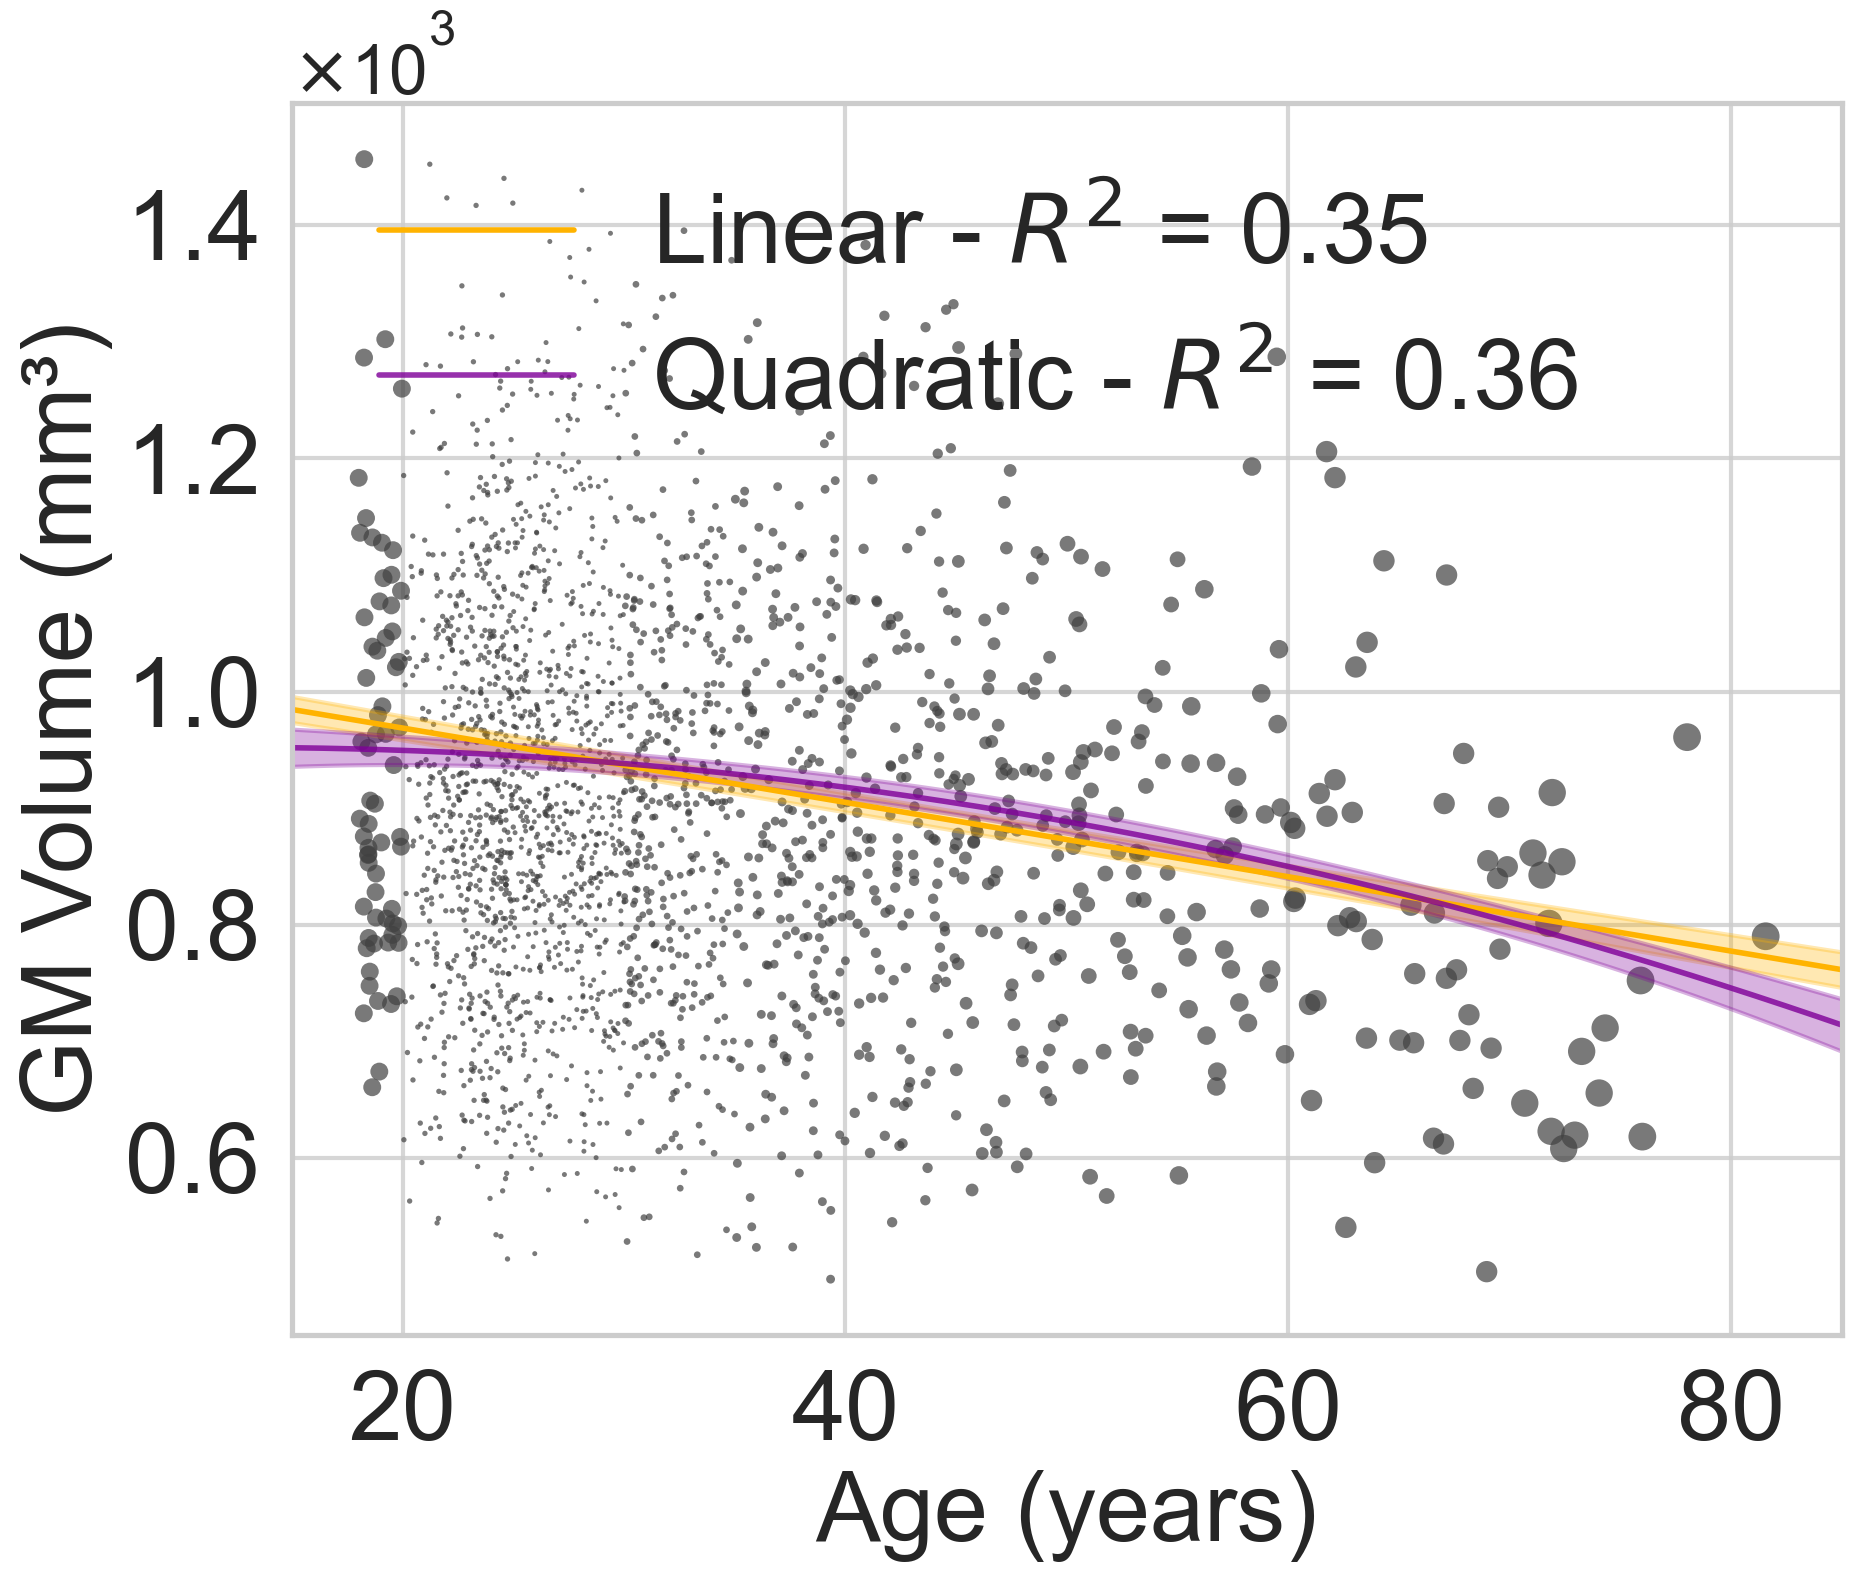

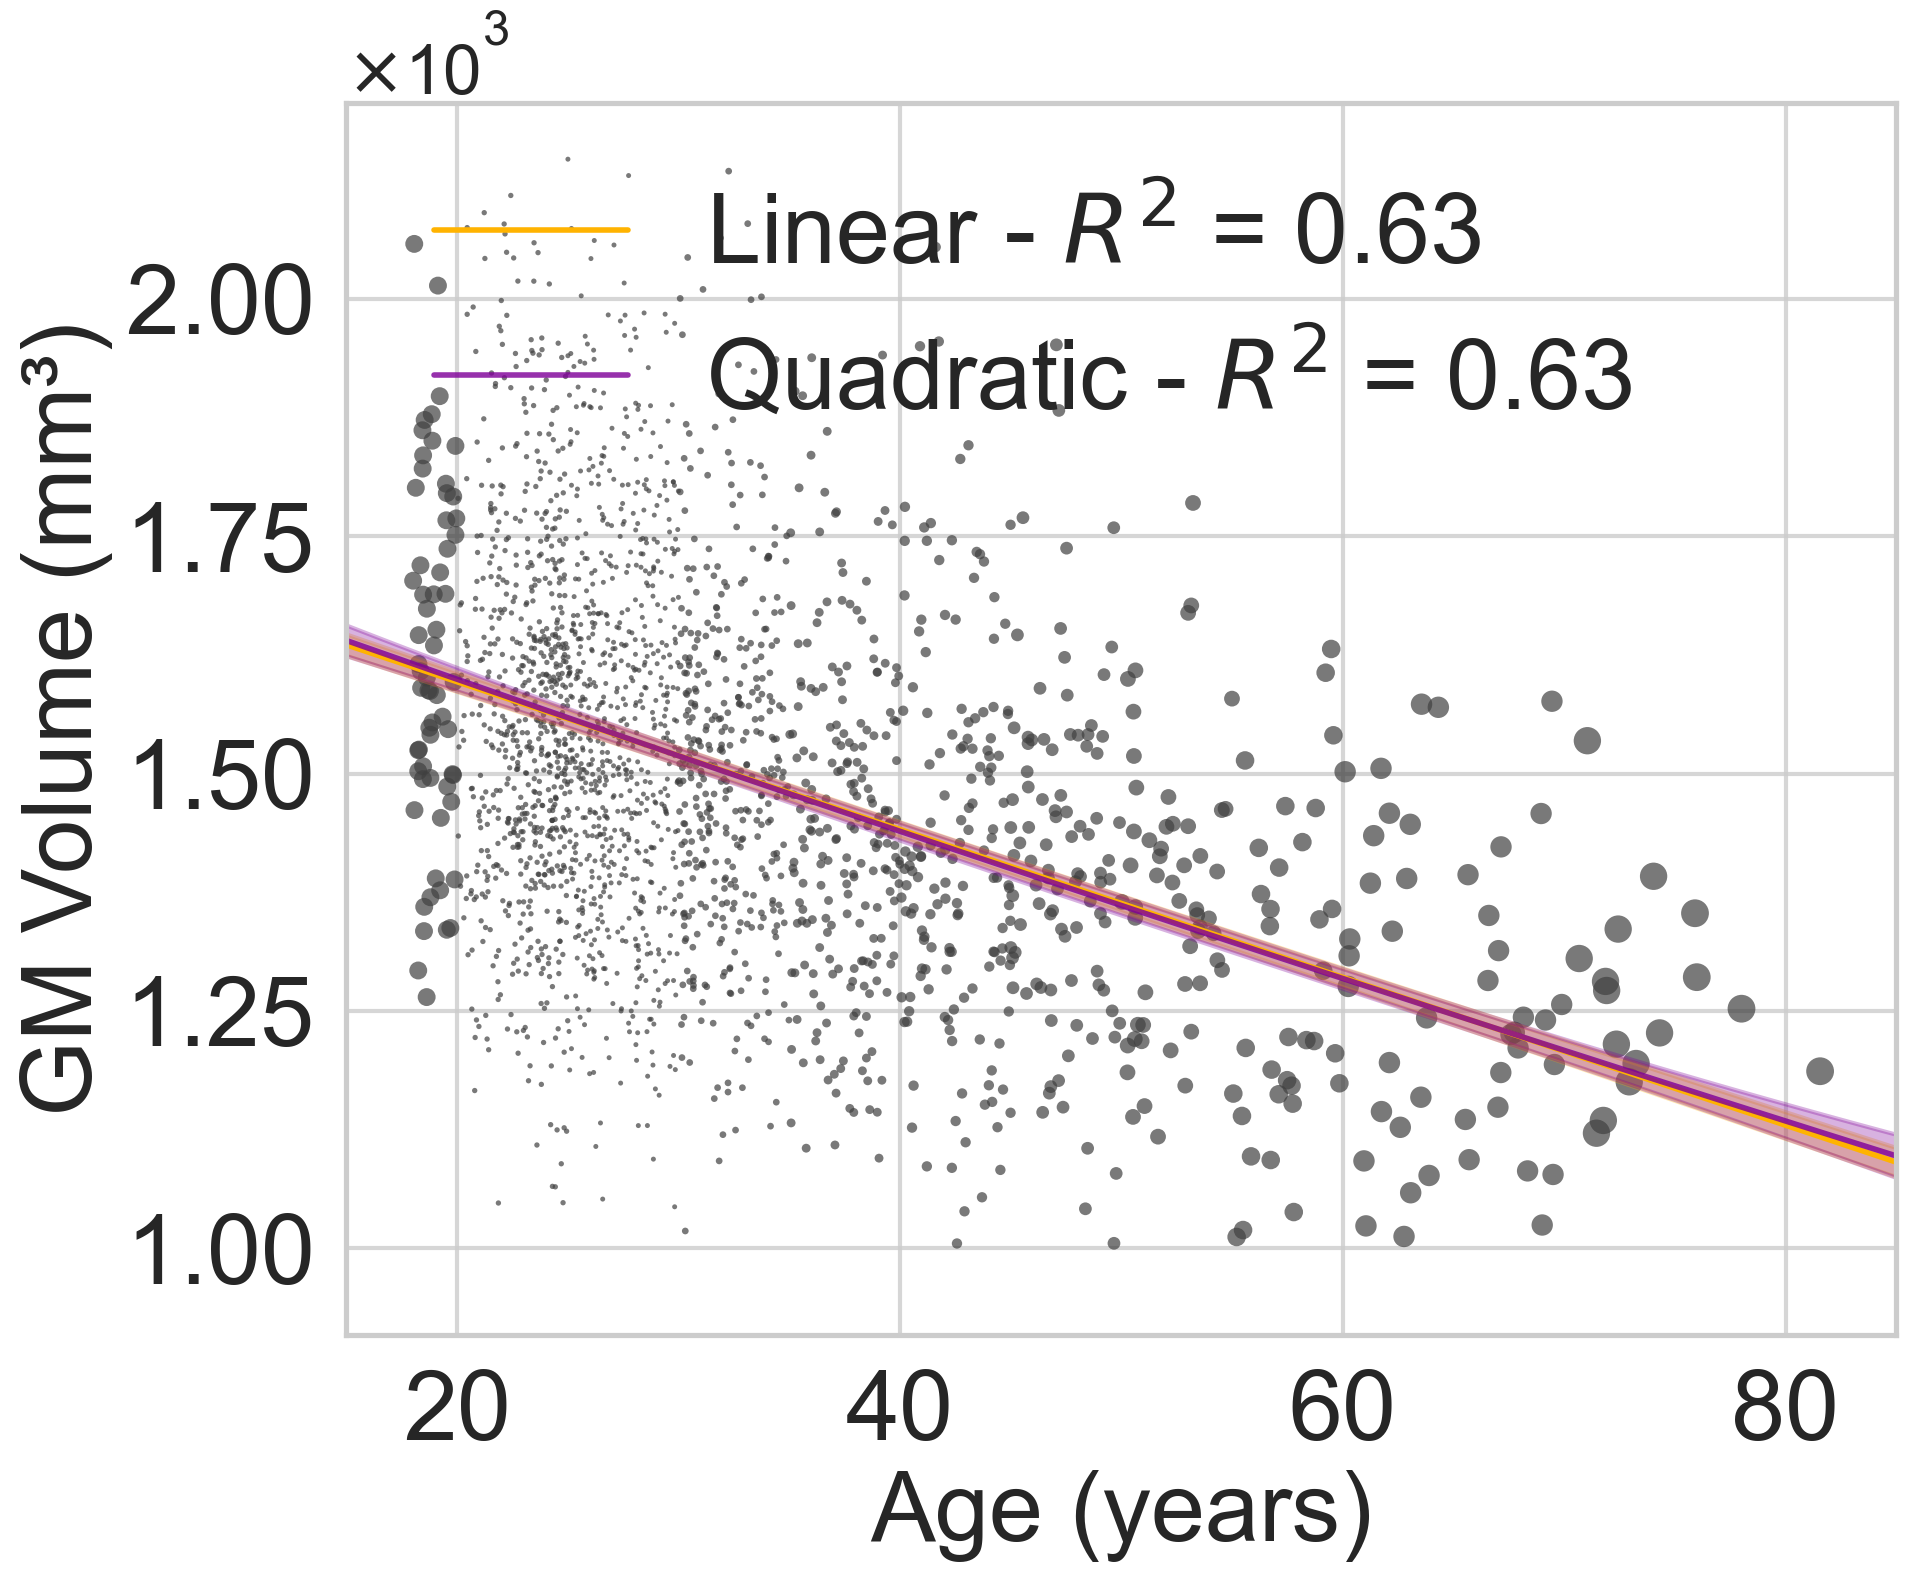

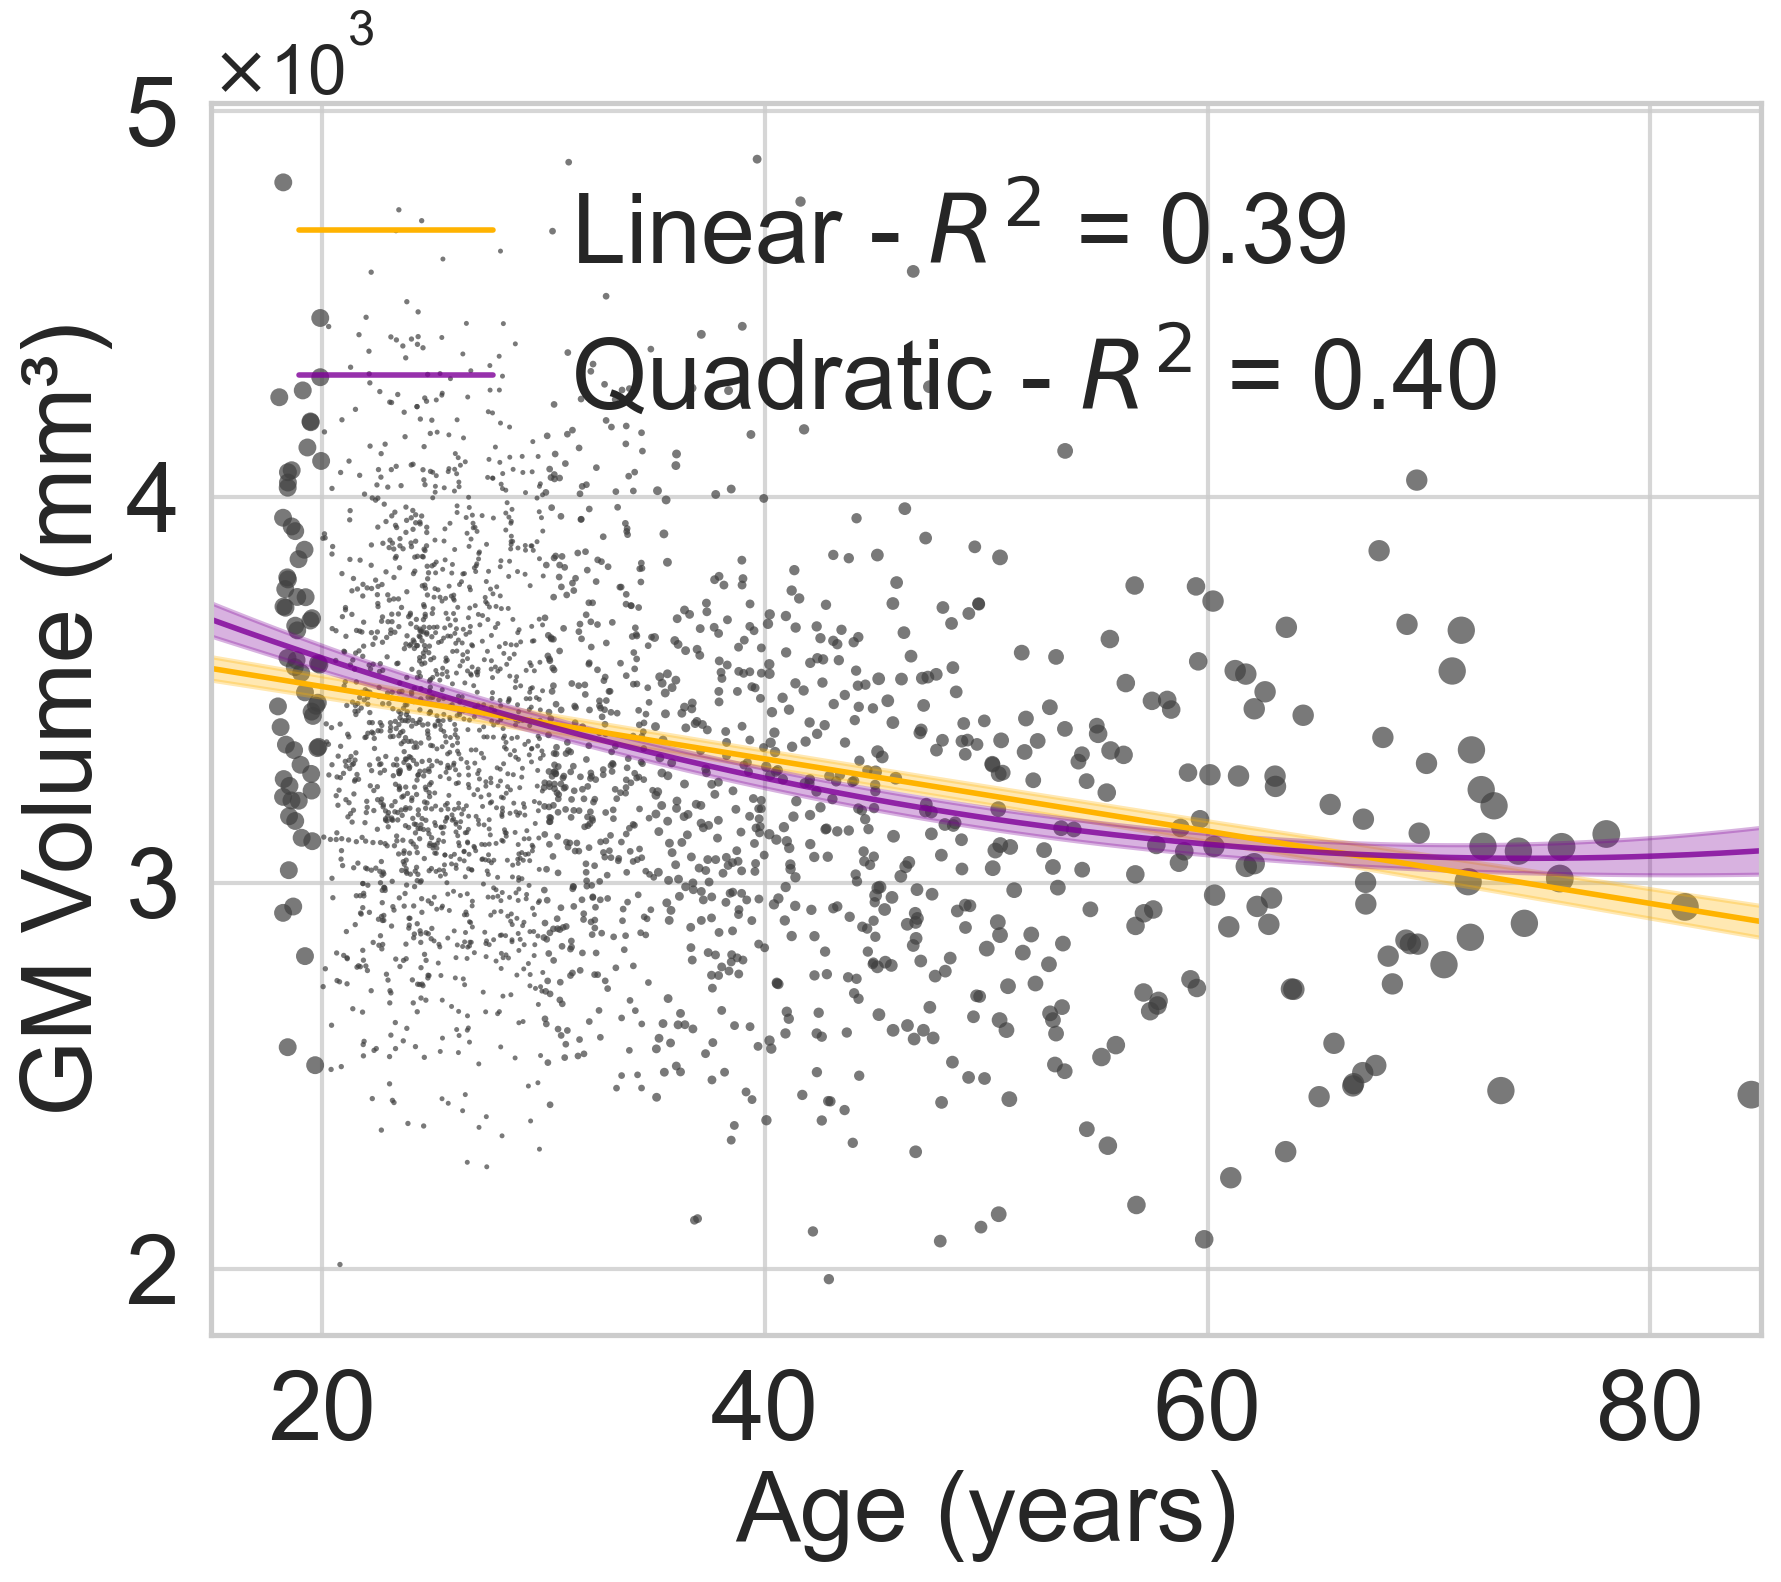

In [176]:
age_min, age_max = 15, 85
age_col = "age_at_scan"

rois = [67, 405] if metric == "gm_vol" else [263, 234]

for cluster in clusters["cluster"].unique():
    # get the most representative region for this cluster
    i = clusters.sort_values(f"probability_{cluster}").index[-1]
    lm = lin_w.loc[i, "model"]
    qm = quad_w.loc[i, "model"]

    d = data[data[region_col] == parcels.loc[i, region_col]].copy()
    # remove outliers
    d = d[
        (d[metric_col] > d[metric_col].quantile(0.001))
        & (d[metric_col] < d[metric_col].quantile(0.999))
    ]
    # d = d[(d[metric_col] > d[metric_col].quantile(0.001))]

    # ────────────────── Panel B: Predicted trajectory ± 95 % CI ──────────────

    mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

    fig, ax = plt.subplots(figsize=(10, 8))

    # 3. Prediction frame

    # ── 3. Prediction grid ──────────────────────────────────────────────
    age_grid = np.linspace(age_min, age_max, 300)
    grid_df = pd.DataFrame({age_col: age_grid, "age_squared": age_grid**2})

    # add any covariates present in models (use median/mode)
    covs = [
        v for v in qm.model.exog_names if v not in ["Intercept", age_col, "I(age_at_scan ** 2)"]
    ]
    for c in covs:
        if pd.api.types.is_numeric_dtype(data[c]):
            grid_df[c] = d[c].median()
        else:
            grid_df[c] = d[c].mode()[0]

    # 4. Get predictions & CI
    for tag, model in [("Linear", lm), ("Quadratic", qm)]:
        pr = model.get_prediction(grid_df)
        ci = pr.conf_int(alpha=0.05)
        grid_df[f"{tag}_fit"] = pr.predicted_mean
        grid_df[f"{tag}_lo"] = ci[:, 0]
        grid_df[f"{tag}_hi"] = ci[:, 1]

    # 5. Plot
    ax.clear()  # reuse the same axes handle

    # Background scatter (down-sample for speed / clarity)
    sizes = np.clip(d["weight"] * 10, 0, 100)
    sns.scatterplot(
        data=d,
        x=age_col,
        y=metric_col,
        alpha=0.7,
        s=sizes,
        edgecolor="none",
        ax=ax,
        legend=False,
        color=COL_REF,
    )

    # # Fit lines & ribbons
    for tag, color, model in zip(["Linear", "Quadratic"], [COL_RAW, COL_WEIGHTED], [lm, qm]):
        # label = f"{tag} - $R^2$ = {model.rsquared:.2f}, AIC = {int(np.round(model.aic)):d}"
        label = f"{tag} - $R^2$ = {model.rsquared:.2f}"
        ax.plot(age_grid, grid_df[f"{tag}_fit"], label=label, lw=2, color=color)
        ax.fill_between(
            age_grid,
            grid_df[f"{tag}_lo"],
            grid_df[f"{tag}_hi"],
            color=color,
            alpha=0.3,
        )

    # add age star
    # stab_age = stab_df.loc[i, "age_star"]

    # if stab_age > 18:
    #     lab = f"Peak Structural Integrity (APSI) = {stab_age:.1f} years"
    # else:
    #     lab = f"Peak Structural Integrity (APSI) ≤ {stab_age:.1f} years"

    # ax.axvline(
    #     stab_age,
    #     color="green",
    #     linestyle="--",
    #     lw=3,
    #     label=lab,
    # )

    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0), useMathText=True)
    if metric == "gm_vol":
        ylabel = "GM Volume (mm³)"
        # set y axis format to cm instead of mm
    else:
        ylabel = "MD (mm²/s)"

    ax.set(
        xlabel="Age (years)",
        ylabel=ylabel,
        xlim=(age_min, age_max),
    )

    # change tick size
    ax.tick_params(axis="both", which="major", labelsize=35)
    # title = "(A) GM Volume" if metric == "gm_vol" else "(B) Mean Diffusivity"
    # suptitle = example_rois.get(i, {}).get("name", f"Region {i}")

    # ax.set_title("Predicted trajectory (± 95 % CI)")
    # ax.set_title(title, fontsize=30, pad=20)
    ax.legend(frameon=False, fontsize=35, loc="upper left")

    # model_type = "quad" if use_quadratic else "linear"
    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"fig2_{metric}_{i+1}.png",
    #     tight=True,
    #     dpi=300,
    # )